# EE4685: Assignment 2  
**Student Names:** Adam El Haddouchi (5476526) & Naufal El Khatibi (5315778)  
**Date:** March 2026  

## Introduction
In this notebook, we study **credit card fraud detection** using machine learning. The goal is to classify fraudulent credit card transactions while dealing with the strong class imbalance present in the dataset.

We compare **non-Bayesian** and **Bayesian** approaches and discuss their strengths and limitations, as required by the assignment. Beyond raw predictive performance, we also consider uncertainty quantification and how it can inform operational decisions (e.g., routing uncertain predictions to a human reviewer).

## Dataset
The dataset was created by the Machine Learning Group at Universite Libre de Bruxelles (Dal Pozzolo, 2015) and contains credit card transactions made by European cardholders in **September 2013** over a period of **two days**. It consists of **284,807 transactions**, of which only **492 are fraudulent**. The positive class represents only **0.172%** of the data, making this a highly imbalanced classification problem.

Most input features are anonymized due to confidentiality constraints. The variables **V1** to **V28** are the result of a **PCA transformation** applied to the original transaction features. The only variables that were not transformed are:

- **Time**: the number of seconds elapsed between each transaction and the first transaction in the dataset  
- **Amount**: the transaction amount  
- **Class**: the target variable, where `1` indicates fraud and `0` indicates a normal transaction  

**Source:** Dal Pozzolo, A. (2015). *Adaptive Machine Learning for Credit Card Fraud Detection.* PhD Thesis, ULB. Dataset available on [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

Because of the extreme class imbalance, standard accuracy is not useful here. A classifier that predicts "normal" for everything already reaches 99.83%. We therefore focus on metrics better suited to imbalanced problems, primarily **AUPRC** (Area Under the Precision-Recall Curve), alongside precision, recall, F1-score, ROC-AUC, and confusion matrices.

## Notebook Overview

1. **Understanding the data** - We inspect the dataset, class balance, and feature structure.
2. **Exploratory data analysis** - We look at feature distributions and check for data quality issues.
3. **Preprocessing and setup** - We prepare the data for modeling and define the experimental setup to avoid leakage.
4. **Modeling** - We implement and compare supervised and anomaly-detection methods, using both Bayesian and non-Bayesian formulations.
5. **Evaluation and discussion** - We evaluate using metrics suited to imbalanced data and discuss trade-offs between the approaches.

## 1. Dataset Loading and Exploration

We start by loading the dataset and inspecting its structure: shape, data types, missing values, summary statistics, and class distribution.

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

# plot styling
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})
sns.set_style("whitegrid")

# load data
df = pd.read_csv("../data/creditcard.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 284807 rows, 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [307]:
# basic info: shape, types, missing values
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\n--- Summary statistics ---")
df.describe()

Shape: (284807, 31)

Data types:
float64    30
int64       1
Name: count, dtype: int64

Missing values: 0

--- Summary statistics ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class distribution:
  Normal (0): 284,315
  Fraud  (1): 492
  Fraud rate:  0.1727%
  Imbalance ratio: 1 : 577


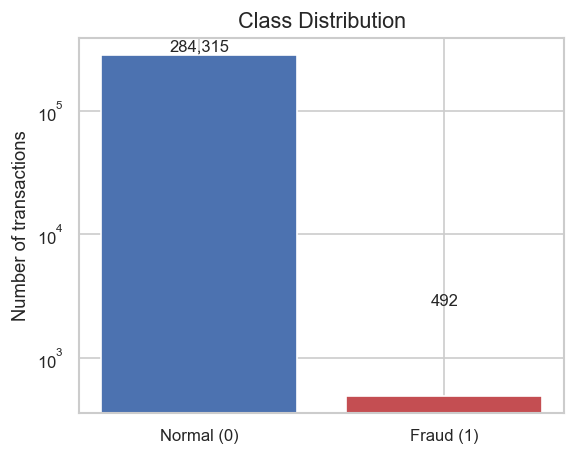

In [308]:
# class distribution - fraud is class 1
class_counts = df["Class"].value_counts().sort_index()
fraud_rate = class_counts[1] / len(df) * 100

print("Class distribution:")
print(f"  Normal (0): {class_counts[0]:,}")
print(f"  Fraud  (1): {class_counts[1]:,}")
print(f"  Fraud rate:  {fraud_rate:.4f}%")
print(f"  Imbalance ratio: 1 : {class_counts[0] // class_counts[1]}")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Normal (0)", "Fraud (1)"], class_counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of transactions")
ax.set_title("Class Distribution")
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
ax.set_yscale("log")  # log scale since normal dwarfs fraud
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The dataset contains 284,807 transactions across 31 columns, all stored as `float64` except for the integer target variable `Class`. There are no missing values.

The V1 through V28 features come from PCA applied by the dataset creators. Their means are effectively zero (order of $10^{-15}$) and their standard deviations range from about 1.96 (V1) down to 0.33 (V28), so they are centered but not uniformly scaled. This spread of roughly 6x in standard deviation will matter for distance-based models later. `Amount` has a mean of 88.35 with a standard deviation of 250.12 (range 0 to 25,691), and `Time` ranges from 0 to 172,792 seconds (about two days). These two features are on very different scales from the V-features and will need standardization during preprocessing.

The class distribution confirms the extreme imbalance: 284,315 normal transactions versus only 492 fraudulent ones, a fraud rate of 0.1727% and an imbalance ratio of roughly 577:1. A trivial "predict all normal" classifier would achieve 99.83% accuracy, which is why we use AUPRC as our primary evaluation metric instead.

## 2. Exploratory Data Analysis

Before modeling, we explore the distributions of key features and how they differ between legitimate and fraudulent transactions. This helps inform preprocessing choices and gives a sense of which features might be useful for classification.

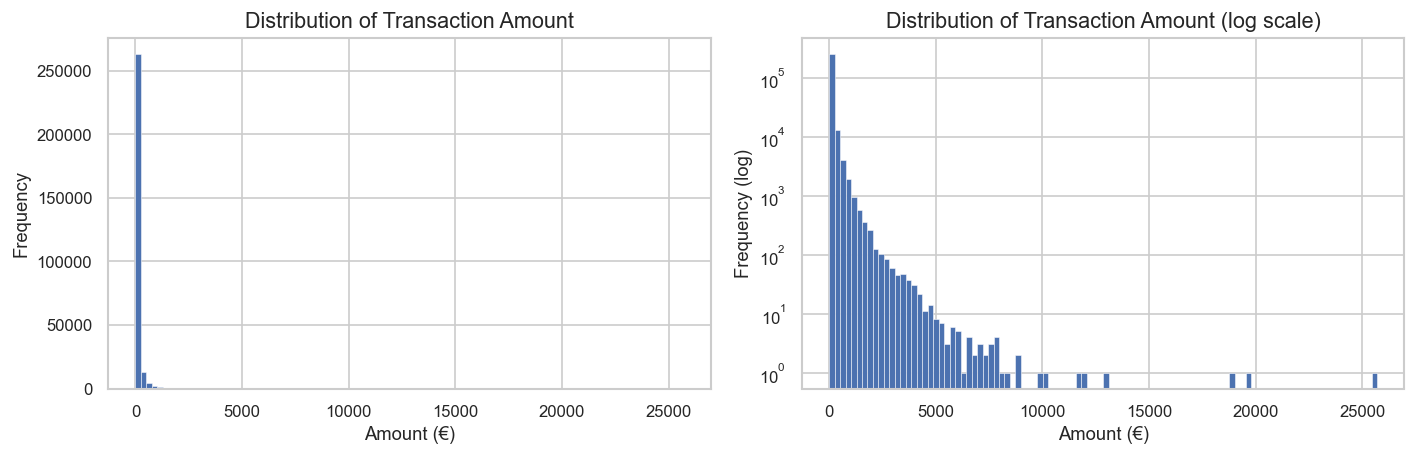

Amount statistics:
  Median: €22.00
  Mean:   €88.35
  Max:    €25691.16
  Skewness: 16.98
  % zero: 0.64%


In [309]:
# distribution of transaction Amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Amount"], bins=100, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].set_title("Distribution of Transaction Amount")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Frequency")

# log scale to see the tail better
axes[1].hist(df["Amount"], bins=100, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[1].set_title("Distribution of Transaction Amount (log scale)")
axes[1].set_xlabel("Amount (€)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("../figures/amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Amount statistics:")
print(f"  Median: €{df['Amount'].median():.2f}")
print(f"  Mean:   €{df['Amount'].mean():.2f}")
print(f"  Max:    €{df['Amount'].max():.2f}")
print(f"  Skewness: {df['Amount'].skew():.2f}")
print(f"  % zero: {(df['Amount'] == 0).mean() * 100:.2f}%")

The distribution of transaction amounts is heavily right-skewed (skewness ~17). The median is only €22.00 while the mean is €88.35, reflecting the long right tail that extends up to €25,691. Most transactions are concentrated at low values, and 0.64% are exactly zero. The log-scale histogram shows that transactions span several orders of magnitude. A `log1p` transform (log because of the skew, the "+1" because of the zeros) followed by standardization seems appropriate for preprocessing.

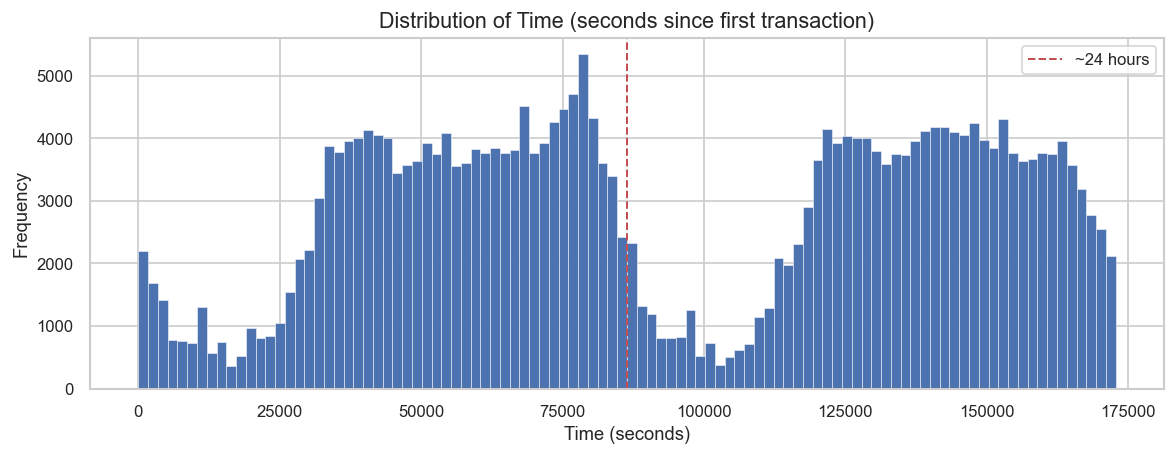

Time statistics:
  Min:  0s
  Max:  172792s  (48.0 hours)
  Span: 2.00 days


In [310]:
# distribution of Time (seconds since first transaction)
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df["Time"], bins=100, color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.set_title("Distribution of Time (seconds since first transaction)")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Frequency")

# mark the approximate day boundary
seconds_per_day = 86400
ax.axvline(x=seconds_per_day, color="#C44E52", linestyle="--", linewidth=1.2, label="~24 hours")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Time statistics:")
print(f"  Min:  {df['Time'].min():.0f}s")
print(f"  Max:  {df['Time'].max():.0f}s  ({df['Time'].max()/3600:.1f} hours)")
print(f"  Span: {df['Time'].max()/86400:.2f} days")

The `Time` feature spans about 172,792 seconds (~2 days), consistent with the dataset documentation. The histogram shows a clear daily cycle: transaction volume drops during nighttime hours and peaks during the day. This pattern repeats across both days. Like `Amount`, `Time` is not standardized and will need scaling.

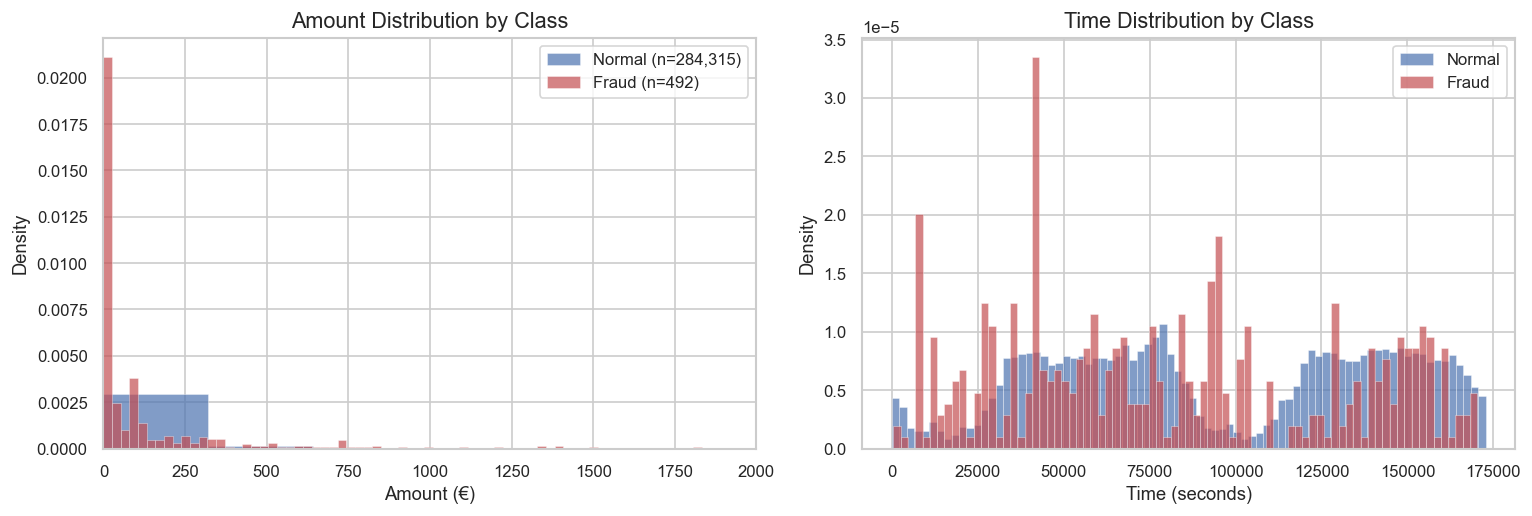

Amount - Normal: mean=€88.29, median=€22.00
Amount - Fraud:  mean=€122.21, median=€9.25

Time - Normal: mean=26.3h
Time - Fraud:  mean=22.4h


In [311]:
# split by class for comparison
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Amount by class (density so we can compare despite different counts)
axes[0].hist(normal["Amount"], bins=80, alpha=0.7, label=f"Normal (n={len(normal):,})",
             color="#4C72B0", density=True, edgecolor="white", linewidth=0.3)
axes[0].hist(fraud["Amount"], bins=80, alpha=0.7, label=f"Fraud (n={len(fraud)})",
             color="#C44E52", density=True, edgecolor="white", linewidth=0.3)
axes[0].set_title("Amount Distribution by Class")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 2000)  # cap at 2000 to see the bulk of the data
axes[0].legend()

# Time by class
axes[1].hist(normal["Time"], bins=80, alpha=0.7, label="Normal",
             color="#4C72B0", density=True, edgecolor="white", linewidth=0.3)
axes[1].hist(fraud["Time"], bins=80, alpha=0.7, label="Fraud",
             color="#C44E52", density=True, edgecolor="white", linewidth=0.3)
axes[1].set_title("Time Distribution by Class")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/amount_time_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Amount - Normal: mean=€{normal['Amount'].mean():.2f}, median=€{normal['Amount'].median():.2f}")
print(f"Amount - Fraud:  mean=€{fraud['Amount'].mean():.2f}, median=€{fraud['Amount'].median():.2f}")
print(f"\nTime - Normal: mean={normal['Time'].mean()/3600:.1f}h")
print(f"Time - Fraud:  mean={fraud['Time'].mean()/3600:.1f}h")

There are some differences between classes, especially for `Amount`. Fraudulent transactions have a higher mean (€122.21 vs. €88.29) but a much lower median (€9.25 vs. €22.00). So most fraudulent transactions are small, but a subset involves larger sums that pull the mean up. This gap between median and mean suggests `Amount` carries some nonlinear discriminative signal even though its linear correlation with `Class` is near zero.

For `Time`, the distributions look broadly similar between classes (mean ~22.4h for fraud vs. ~26.3h for normal). Both follow the same daily cycle. There is no strong evidence that fraud happens preferentially at certain times, so `Time` is likely less useful for classification.

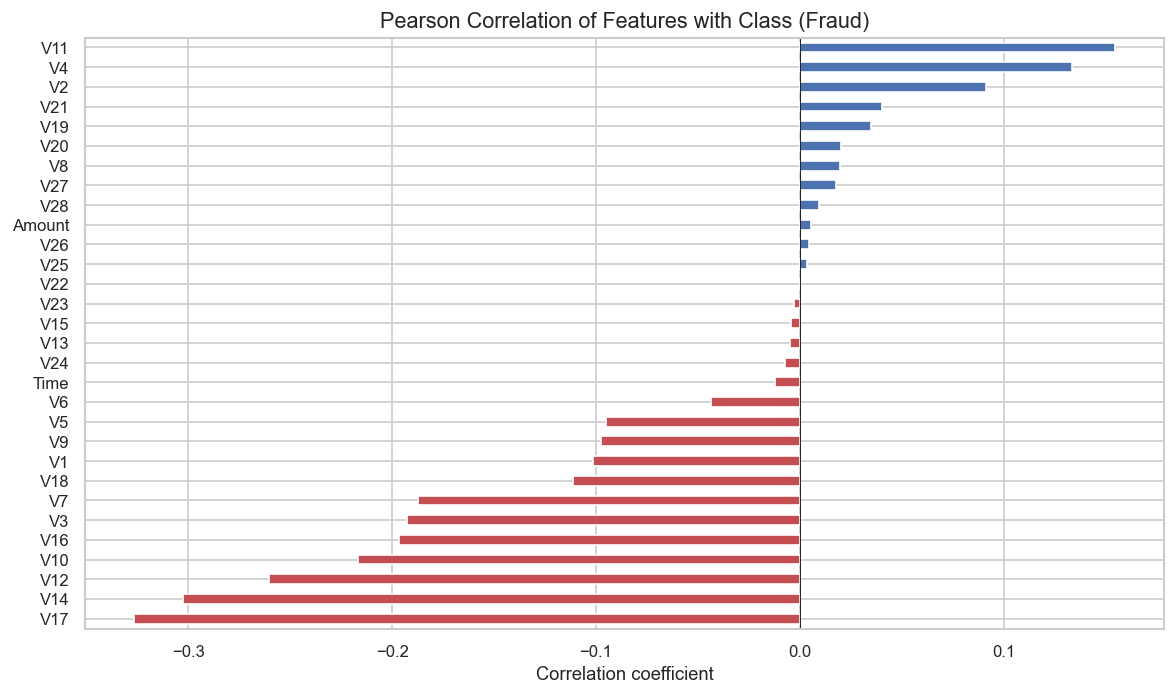

Top 10 features most correlated with fraud (by absolute value):
       V17: -0.3265
       V14: -0.3025
       V12: -0.2606
       V10: -0.2169
       V16: -0.1965
        V3: -0.1930
        V7: -0.1873
       V11: +0.1549
        V4: +0.1334
       V18: -0.1115


In [312]:
# correlation of each feature with the fraud label
v_features = [f"V{i}" for i in range(1, 29)]
all_features = v_features + ["Amount", "Time"]

correlations = df[all_features + ["Class"]].corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in correlations.values]
correlations.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Pearson Correlation of Features with Class (Fraud)")
ax.set_xlabel("Correlation coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("../figures/feature_correlation_with_class.png", dpi=150, bbox_inches="tight")
plt.show()

# top features by absolute correlation
print("Top 10 features most correlated with fraud (by absolute value):")
top_corr = correlations.abs().sort_values(ascending=False).head(10)
for feat, val in top_corr.items():
    sign = "+" if correlations[feat] > 0 else "-"
    print(f"  {feat:>8s}: {sign}{val:.4f}")

Most V-features have weak individual correlations with the fraud label, but a few stand out. The strongest negative correlations (lower values associated with fraud) are V17 (r = -0.33), V14 (r = -0.30), V12 (r = -0.26), V10 (r = -0.22), V16 (r = -0.20), V3 (r = -0.19), and V7 (r = -0.19). On the positive side, V11 (+0.15) and V4 (+0.13) show the strongest associations.

Since V1-V28 are PCA components of unknown original features, we cannot assign any semantic meaning to them. We can only observe that some components carry more discriminative signal than others. `Amount` and `Time` both show negligible linear correlation with `Class` (below 0.01), though the class-conditional analysis above suggested `Amount` may still carry nonlinear information.

The box plots below show the top correlated V-features split by class.

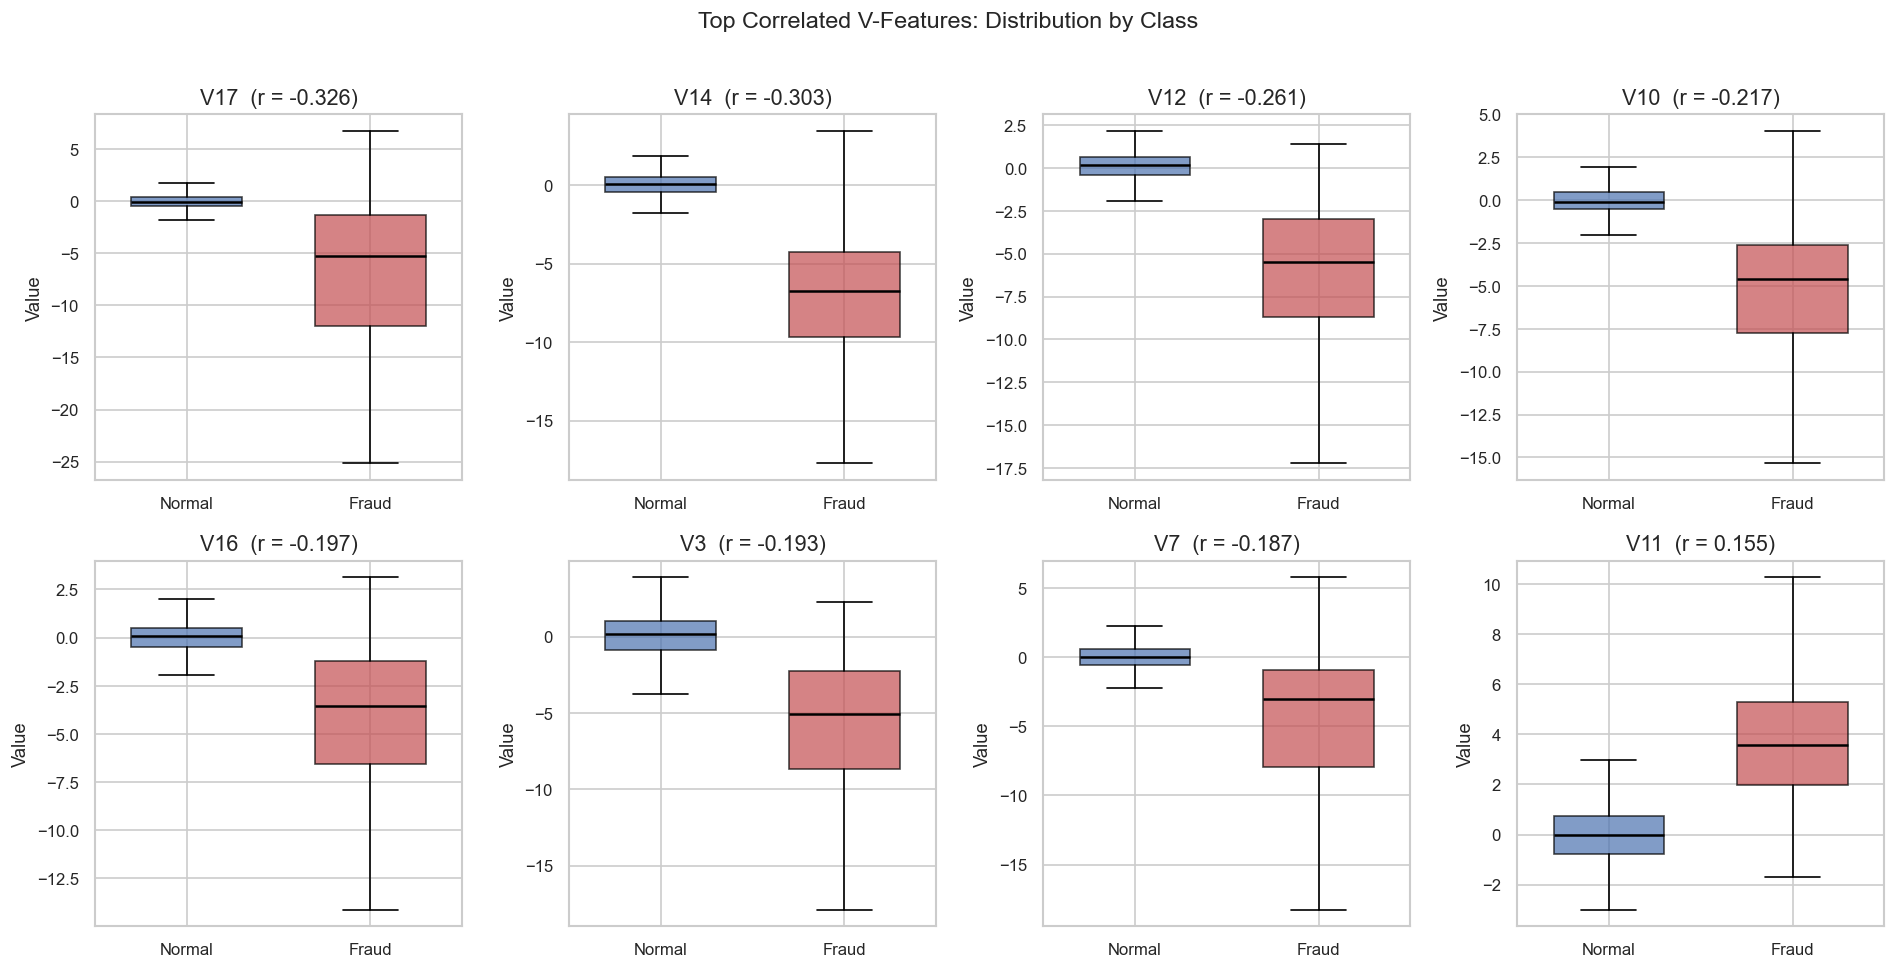

In [313]:
# box plots of the V-features most correlated with fraud
top_features = ["V17", "V14", "V12", "V10", "V16", "V3", "V7", "V11"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = [normal[feat].values, fraud[feat].values]
    bp = axes[i].boxplot(data, labels=["Normal", "Fraud"], patch_artist=True,
                         widths=0.6, showfliers=False,
                         medianprops=dict(color="black", linewidth=1.5))
    bp["boxes"][0].set_facecolor("#4C72B0")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#C44E52")
    bp["boxes"][1].set_alpha(0.7)
    axes[i].set_title(f"{feat}  (r = {correlations[feat]:.3f})")
    axes[i].set_ylabel("Value")

plt.suptitle("Top Correlated V-Features: Distribution by Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/top_v_features_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

The box plots confirm clear distributional shifts between classes for these features. For the negatively correlated features, fraud transactions are concentrated at much lower values than normal ones, with V14 and V12 showing the most pronounced separation. V11 (positively correlated) shows the opposite pattern: fraud transactions tend to have higher values. In all eight features, the interquartile ranges of the two classes have limited overlap, so these components carry meaningful discriminative information even individually.

We cannot say what these PCA components represent in terms of the original transaction features. We can only note that they encode patterns that differ systematically between legitimate and fraudulent activity.

In [314]:
# check for constant or near-constant features
print("Unique values per feature:")
nunique = df[all_features].nunique().sort_values()
print(nunique.to_string())
print(f"\nMin unique values: {nunique.min()} ({nunique.idxmin()})")
print(f"Any constant features (nunique == 1): {(nunique == 1).any()}")

# also check variance as a sanity check
low_var = df[all_features].var().sort_values()
print(f"\nLowest-variance features:")
for feat, var in low_var.head(5).items():
    print(f"  {feat}: var = {var:.4f}")

Unique values per feature:
Amount     32767
Time      124592
V28       275663
V27       275663
V26       275663
V25       275663
V24       275663
V23       275663
V22       275663
V21       275663
V20       275663
V19       275663
V18       275663
V17       275663
V16       275663
V1        275663
V13       275663
V12       275663
V11       275663
V10       275663
V9        275663
V8        275663
V7        275663
V6        275663
V5        275663
V4        275663
V3        275663
V2        275663
V14       275663
V15       275663

Min unique values: 32767 (Amount)
Any constant features (nunique == 1): False

Lowest-variance features:
  V28: var = 0.1090
  V27: var = 0.1629
  V26: var = 0.2325
  V25: var = 0.2717
  V24: var = 0.3668


No features are constant or near-constant. All 30 features have at least tens of thousands of unique values, so there is no reason to drop any feature before modeling. The lowest-variance features are the higher-numbered V-components (V28, V27, V26), which is expected since PCA components are ordered by explained variance.

### EDA Summary

Key takeaways from the exploratory analysis:

- **Class imbalance** is extreme (0.17% fraud). Accuracy is not a useful metric; we will use AUPRC.
- **Amount** is heavily right-skewed and needs a `log1p` transform before standardization. It shows nonlinear discriminative signal (fraud median €9.25 vs. normal median €22.00) despite near-zero linear correlation with Class.
- **Time** shows daily cyclical patterns but similar distributions across classes. Low discriminative value.
- **V-features** are centered (from PCA) but not uniformly scaled (std ranges from 0.33 to 1.96). All features should be standardized, especially for distance-based models like OC-SVM and BGMM.
- **Top discriminative features**: V17 (r = -0.33), V14 (r = -0.30), V12 (r = -0.26), V10 (r = -0.22).
- **No constant or near-constant features** exist; all 30 features are retained.

## 3. Preprocessing and Train/Validation/Test Split

The EDA revealed two preprocessing needs. First, `Amount` is heavily right-skewed (skewness ~17) and contains zero values, so we apply a `log1p` transform to compress the tail before standardization. Second, the V-features have standard deviations ranging from 0.33 (V28) to 1.96 (V1), a 6x spread that would bias distance-based models. We standardize all 30 features (V1-V28, log-transformed Amount, and Time) using `StandardScaler`.

To prevent data leakage, we follow a strict ordering: (1) apply `log1p` to Amount on the full DataFrame, since this is a fixed mathematical transform that does not depend on data statistics; (2) perform a stratified train/validation/test split; (3) fit the scaler on the training set only, then transform all three splits.

For handling the class imbalance, we use `class_weight='balanced'` in supervised models rather than SMOTE. SMOTE generates synthetic minority samples by interpolating between existing ones, but in a 30-dimensional PCA-transformed space where the original feature semantics are unknown, the validity of those interpolated points is questionable. Oversampling also inflates the training set and increases computation time. Adjusting class weights penalizes misclassification of the minority class more heavily without introducing synthetic data points.

In [315]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# log1p transform on Amount (data-independent, safe to do before splitting)
df["LogAmount"] = np.log1p(df["Amount"])

print(f"Amount  -> skewness: {df['Amount'].skew():.2f}, mean: {df['Amount'].mean():.2f}, std: {df['Amount'].std():.2f}")
print(f"LogAmount -> skewness: {df['LogAmount'].skew():.2f}, mean: {df['LogAmount'].mean():.2f}, std: {df['LogAmount'].std():.2f}")

# replace Amount with LogAmount in the feature list, keep Time
features = [f"V{i}" for i in range(1, 29)] + ["LogAmount", "Time"]
print(f"\nFeature set ({len(features)} features): {features[:3]} ... {features[-3:]}")

X = df[features].values
y = df["Class"].values

# stratified split: 80/20 -> train+val / test, then 80/20 -> train / val
# gives us 64/16/20 overall
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=42
)

print(f"\nSplit sizes:")
print(f"  Train:      {X_train.shape[0]:>7,} samples  ({X_train.shape[0]/len(df)*100:.1f}%),  fraud: {y_train.sum():>4}  ({y_train.mean()*100:.3f}%)")
print(f"  Validation: {X_val.shape[0]:>7,} samples  ({X_val.shape[0]/len(df)*100:.1f}%),  fraud: {y_val.sum():>4}  ({y_val.mean()*100:.3f}%)")
print(f"  Test:       {X_test.shape[0]:>7,} samples  ({X_test.shape[0]/len(df)*100:.1f}%),  fraud: {y_test.sum():>4}  ({y_test.mean()*100:.3f}%)")
print(f"  Total:      {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:>7,}")
print(f"\nFraud rate consistency check:")
print(f"  Overall: {y.mean()*100:.4f}%")
print(f"  Train:   {y_train.mean()*100:.4f}%")
print(f"  Val:     {y_val.mean()*100:.4f}%")
print(f"  Test:    {y_test.mean()*100:.4f}%")

Amount  -> skewness: 16.98, mean: 88.35, std: 250.12
LogAmount -> skewness: 0.16, mean: 3.15, std: 1.66

Feature set (30 features): ['V1', 'V2', 'V3'] ... ['V28', 'LogAmount', 'Time']

Split sizes:
  Train:      182,276 samples  (64.0%),  fraud:  315  (0.173%)
  Validation:  45,569 samples  (16.0%),  fraud:   79  (0.173%)
  Test:        56,962 samples  (20.0%),  fraud:   98  (0.172%)
  Total:      284,807

Fraud rate consistency check:
  Overall: 0.1727%
  Train:   0.1728%
  Val:     0.1734%
  Test:    0.1720%


The `log1p` transform reduced the skewness of `Amount` from 16.98 to 0.16, making it roughly symmetric. The standard deviation dropped from 250.12 to 1.66, which is now comparable to the V-features.

The stratified split produced 182,276 training samples (64.0%), 45,569 validation samples (16.0%), and 56,962 test samples (20.0%), totaling 284,807. The fraud rate is consistent across all three splits: 0.173% in train (315 cases), 0.173% in validation (79 cases), and 0.172% in test (98 cases). The stratification preserved the class distribution as intended.

In [316]:
# fit scaler on training set only, then transform all splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)     # transform only, no fitting
X_test = scaler.transform(X_test)   # transform only, no fitting

# sanity check: training set should have mean ~0 and std ~1
train_means = X_train.mean(axis=0)
train_stds = X_train.std(axis=0)

print("Sanity check - training set statistics after scaling:")
print(f"  Mean range: [{train_means.min():.6f}, {train_means.max():.6f}]  (should be ~0)")
print(f"  Std  range: [{train_stds.min():.6f}, {train_stds.max():.6f}]  (should be ~1)")

# spot-check a few features
print(f"\nPer-feature check (first 5 + LogAmount + Time):")
check_idx = [0, 1, 2, 3, 4, 28, 29]  # V1-V5, LogAmount, Time
for i in check_idx:
    print(f"  {features[i]:>10s}: mean = {train_means[i]:+.6f}, std = {train_stds[i]:.6f}")

# normal-only training set for anomaly detection models
X_train_normal = X_train[y_train == 0]
print(f"\nAnomaly detection training set (normal only): {X_train_normal.shape[0]:,} samples")
print(f"  Fraud excluded: {y_train.sum()} samples")
print(f"\nFinal array shapes:")
print(f"  X_train:        {X_train.shape}")
print(f"  X_val:          {X_val.shape}")
print(f"  X_test:         {X_test.shape}")
print(f"  X_train_normal: {X_train_normal.shape}")

Sanity check - training set statistics after scaling:
  Mean range: [-0.000000, 0.000000]  (should be ~0)
  Std  range: [1.000000, 1.000000]  (should be ~1)

Per-feature check (first 5 + LogAmount + Time):
          V1: mean = -0.000000, std = 1.000000
          V2: mean = -0.000000, std = 1.000000
          V3: mean = +0.000000, std = 1.000000
          V4: mean = +0.000000, std = 1.000000
          V5: mean = +0.000000, std = 1.000000
   LogAmount: mean = -0.000000, std = 1.000000
        Time: mean = +0.000000, std = 1.000000

Anomaly detection training set (normal only): 181,961 samples
  Fraud excluded: 315 samples

Final array shapes:
  X_train:        (182276, 30)
  X_val:          (45569, 30)
  X_test:         (56962, 30)
  X_train_normal: (181961, 30)


After scaling, all 30 features have mean 0 and standard deviation 1 on the training set, confirming the scaler was applied correctly. The scaler was fit on the training set only and then used to transform the validation and test sets, so there is no information leakage.

For the anomaly detection models (OC-SVM, BGMM, Autoencoder), we created a separate training set containing only the 181,961 normal transactions from the training split. These models learn the distribution of normal behavior and flag deviations as potential fraud. The 315 fraudulent training samples are excluded from this set but remain available in the full training set for supervised models.

The preprocessing pipeline is now complete. To summarize the setup going forward:
- **Supervised models** (Logistic Regression, Bayesian Logistic Regression): train on `X_train`, `y_train` with `class_weight='balanced'`, tune on `X_val`, `y_val`, evaluate on `X_test`, `y_test`.
- **Anomaly detection models** (OC-SVM, BGMM, Autoencoder): train on `X_train_normal`, tune thresholds on `X_val`, `y_val`, evaluate on `X_test`, `y_test`.

## 4. Evaluation Framework

Before building any models, we establish the evaluation criteria. The extreme class imbalance in this dataset (0.17% fraud) makes standard metrics unreliable, and different model families require different evaluation considerations. This section lays out our metric choices and their justification.

### Why AUPRC is the primary metric

The Area Under the Precision-Recall Curve (AUPRC) is our primary evaluation metric. This choice is motivated by the class imbalance: with only 492 fraudulent transactions out of 284,807, metrics that depend on the large number of true negatives give an inflated picture of model quality.

Davis and Goadrich (2006) showed that precision-recall curves provide a more informative picture than ROC curves when datasets are heavily skewed, because precision is directly sensitive to false positives without dilution from the large negative class. ROC curves use the false positive rate, FPR = FP / (FP + TN), as the x-axis. When TN is enormous (here ~284,000), even hundreds of false positives barely move the FPR, making the ROC curve look deceptively good. Precision, on the other hand, is TP / (TP + FP), which exposes false positives directly.

Saito and Rehmsmeier (2015) provided further empirical evidence that ROC plots can be visually deceptive for imbalanced datasets, and recommended precision-recall plots as the default for such problems. Their study showed that classifiers with near-identical ROC curves can have very different precision-recall profiles, meaning ROC-AUC can fail to distinguish between models that differ substantially in practical performance.

We still report ROC-AUC as a secondary metric for completeness, but all model comparisons and conclusions are based on AUPRC.

### Why accuracy is useless here

To make the case concrete, consider the simplest possible classifier: one that predicts "normal" for every transaction, regardless of input.

In [317]:
# trivial classifier: predict "normal" for everything
n_total = len(y)
n_normal = (y == 0).sum()
trivial_accuracy = n_normal / n_total

print(f"Trivial 'predict all normal' classifier:")
print(f"  Correct predictions: {n_normal:,} out of {n_total:,}")
print(f"  Accuracy: {trivial_accuracy * 100:.2f}%")
print(f"  Frauds detected: 0 out of {(y == 1).sum()}")
print(f"  Recall: 0.00%")

Trivial 'predict all normal' classifier:
  Correct predictions: 284,315 out of 284,807
  Accuracy: 99.83%
  Frauds detected: 0 out of 492
  Recall: 0.00%


A classifier that blindly labels every transaction as legitimate achieves 99.83% accuracy. It is, of course, completely useless: it catches zero fraud. This demonstrates why accuracy is not a meaningful metric for this problem. Any model we build must be evaluated on its ability to identify the rare positive class, not on its ability to correctly label the overwhelming majority of normal transactions.

### Evaluation protocol for supervised vs anomaly detection models

Our model lineup includes two types of learners that differ in what training data they see. Supervised models (Logistic Regression and Bayesian Logistic Regression) are trained on both normal and fraudulent transactions, with access to the class labels. Anomaly detection models (One-Class SVM, Bayesian Gaussian Mixture Model, and Autoencoder) are trained on normal transactions only and have never seen a fraudulent example during training. This information asymmetry means that comparing the two groups is not an apples-to-apples exercise.

To keep the comparison fair where possible, all models are evaluated on the same held-out test set using the same metrics (AUPRC, ROC-AUC, precision, recall, F1, and confusion matrices). The test set was not used during training or threshold tuning for any model. Thresholds are tuned on the validation set for all models (Phase 9). The key interpretive point is that supervised models have a structural advantage: they were told what fraud looks like. If an anomaly detector approaches supervised performance despite this handicap, that is a strong result. If it falls short, the gap quantifies how much labeled fraud data is worth in this setting.

## 5. Supervised Models

### 5.1 Logistic Regression (Non-Bayesian Baseline)

Logistic Regression is our starting point for binary classification. It models the log-odds of the positive class as a linear function of the input features and outputs calibrated probabilities through the sigmoid function. In fraud detection, LR is one of the most commonly deployed models in production (Dal Pozzolo et al., 2014), partly because it is interpretable and computationally cheap.

In our project, LR is the non-Bayesian supervised baseline. All other models will be compared against it, and if a more complex model does not clearly beat LR, that is itself a useful finding. We use `class_weight='balanced'` to handle the class imbalance. This scales the loss contribution of each class inversely proportional to its frequency, giving the 315 fraud samples in the training set roughly 577 times more weight per sample than the normal transactions.

In [318]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
    confusion_matrix, classification_report, f1_score
)

# train logistic regression with balanced class weights
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

# predict on validation set
lr_val_probs = lr_model.predict_proba(X_val)[:, 1]  # probability of fraud
lr_val_preds = lr_model.predict(X_val)               # binary predictions at default 0.5 threshold

print(f"Logistic Regression trained on {X_train.shape[0]:,} samples ({y_train.sum()} fraud)")
print(f"Validation set: {X_val.shape[0]:,} samples ({y_val.sum()} fraud)")
print(f"\nCoefficients shape: {lr_model.coef_.shape}")
print(f"Intercept: {lr_model.intercept_[0]:.4f}")
print(f"Number of iterations: {lr_model.n_iter_[0]}")

Logistic Regression trained on 182,276 samples (315 fraud)
Validation set: 45,569 samples (79 fraud)

Coefficients shape: (1, 30)
Intercept: -4.1182
Number of iterations: 21


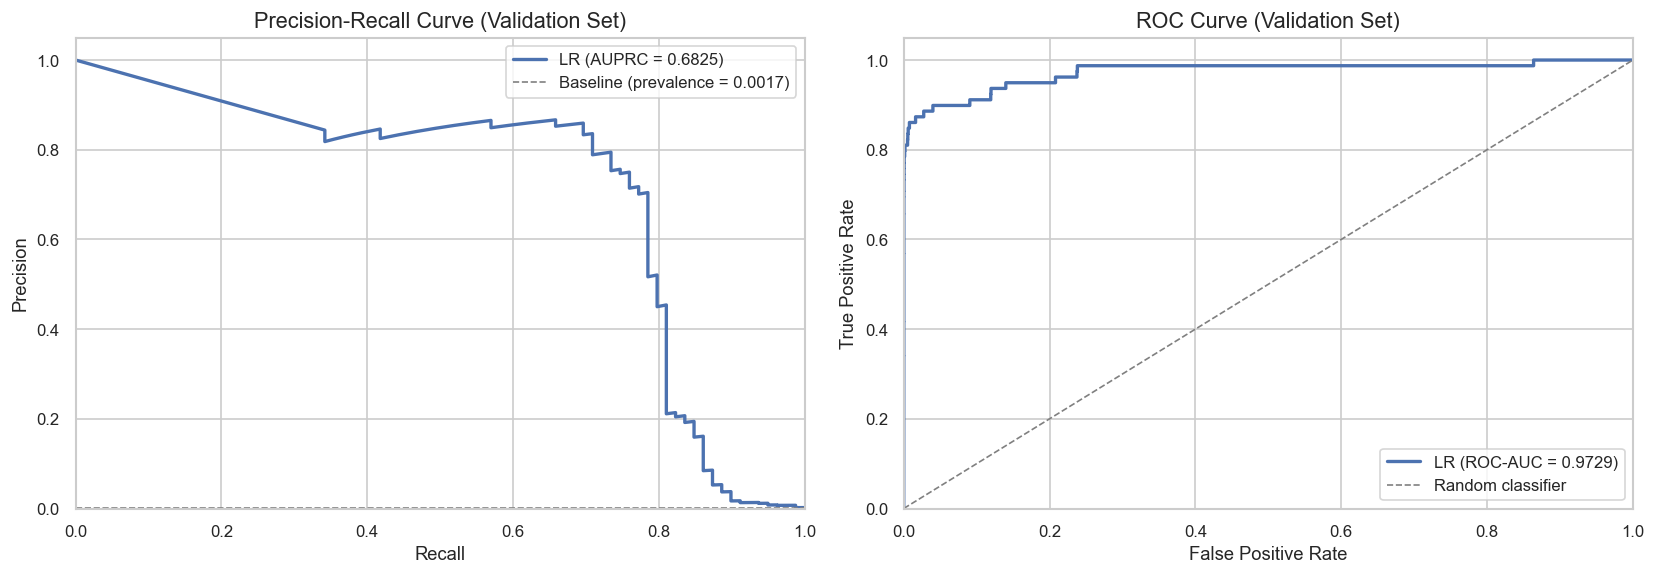

AUPRC:   0.6825
ROC-AUC: 0.9729


In [319]:
# PR curve and ROC curve for LR on the validation set
lr_precision, lr_recall, lr_pr_thresholds = precision_recall_curve(y_val, lr_val_probs)
lr_auprc = average_precision_score(y_val, lr_val_probs)

lr_fpr, lr_tpr, lr_roc_thresholds = roc_curve(y_val, lr_val_probs)
lr_roc_auc = roc_auc_score(y_val, lr_val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve - more informative for imbalanced data
axes[0].plot(lr_recall, lr_precision, color="#4C72B0", linewidth=2, label=f"LR (AUPRC = {lr_auprc:.4f})")
axes[0].axhline(y=y_val.mean(), color="gray", linestyle="--", linewidth=1, label=f"Baseline (prevalence = {y_val.mean():.4f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Validation Set)")
axes[0].legend(loc="upper right")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# ROC curve - will look good due to large TN count
axes[1].plot(lr_fpr, lr_tpr, color="#4C72B0", linewidth=2, label=f"LR (ROC-AUC = {lr_roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Validation Set)")
axes[1].legend(loc="lower right")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig("../figures/lr_pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUPRC:   {lr_auprc:.4f}")
print(f"ROC-AUC: {lr_roc_auc:.4f}")

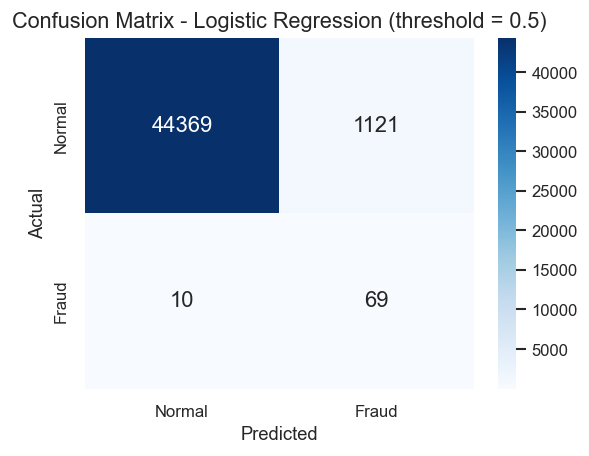

Confusion matrix (threshold = 0.5):
  True Negatives:  44,369
  False Positives:  1,121
  False Negatives:     10
  True Positives:      69

Precision: 0.0580
Recall:    0.8734
F1 Score:  0.1087

Note: these metrics use the default 0.5 threshold.
Threshold tuning on the validation set will be done in Phase 9.


In [320]:
# confusion matrix and classification metrics at default 0.5 threshold
lr_cm = confusion_matrix(y_val, lr_val_preds)
lr_f1 = f1_score(y_val, lr_val_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Logistic Regression (threshold = 0.5)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_lr.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = lr_cm.ravel()
print(f"Confusion matrix (threshold = 0.5):")
print(f"  True Negatives:  {tn:>6,}")
print(f"  False Positives: {fp:>6,}")
print(f"  False Negatives: {fn:>6,}")
print(f"  True Positives:  {tp:>6,}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall:    {tp/(tp+fn):.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"\nNote: these metrics use the default 0.5 threshold.")
print(f"Threshold tuning on the validation set will be done in Phase 9.")

The Logistic Regression model converged in 21 iterations. On the validation set, it achieves an AUPRC of 0.6825 and a ROC-AUC of 0.9729. The gap between these two numbers is telling: ROC-AUC looks high because the false positive rate denominator includes all ~45,490 actual negatives, which dilutes even a large number of false positives. AUPRC uses precision instead of FPR, giving a less optimistic but more practically useful picture.

At the default 0.5 classification threshold, the model catches 69 out of 79 fraudulent transactions (recall = 0.87) but generates 1,121 false positives, giving a precision of just 5.8%. That means roughly 94% of fraud alerts at this threshold are false alarms. The F1 score is 0.109, which reflects this extreme precision-recall tradeoff. The `class_weight='balanced'` setting pushed the model toward high recall, but at the cost of many false positives. Using `class_weight='balanced'` also slightly affects the learned coefficients compared to an unweighted model and may modestly reduce AUPRC, but we use it for consistency with the plan's imbalance handling strategy across all supervised models.

These numbers use the default 0.5 threshold, which is not optimal for a problem with a 0.17% base rate. Threshold tuning on the validation set in Phase 9 should improve the F1 by finding a better operating point on the precision-recall curve. For now, the AUPRC of 0.6825 is the threshold-independent summary of LR's performance and serves as our baseline for all subsequent models.

### 5.2 Bayesian Logistic Regression

Logistic Regression produces a single point estimate for each weight parameter by maximizing the (penalized) log-likelihood. Bayesian Logistic Regression treats the weight vector as a random variable with a prior distribution and computes a posterior distribution over weights given the training data. Instead of a single predicted probability for each transaction, the model yields a distribution of predicted probabilities, which lets us quantify how uncertain the model is about each prediction.

The posterior over the weights is intractable for logistic regression because the logistic likelihood does not conjugate with a Gaussian prior (Bishop, 2006, Ch. 4). We therefore use the Laplace approximation: we find the mode of the posterior (which coincides with the MAP estimate, equivalent to L2-regularized logistic regression) and fit a Gaussian centered at that mode, with covariance equal to the inverse of the Hessian of the negative log-posterior evaluated at the mode. This gives us a tractable Gaussian approximation to the posterior: $p(\mathbf{w} | \mathcal{D}) \approx \mathcal{N}(\mathbf{w}_\text{MAP}, \mathbf{H}^{-1})$, where $\mathbf{H}$ is the Hessian of the negative log-posterior.

To generate predictions with uncertainty, we propagate the posterior weight distribution through the logistic function. For each test point $\mathbf{x}$, the logit $a = \mathbf{w}^\top \mathbf{x}$ is approximately Gaussian with mean $\mu_a = \mathbf{w}_\text{MAP}^\top \mathbf{x}$ and variance $\sigma_a^2 = \mathbf{x}^\top \mathbf{H}^{-1} \mathbf{x}$. We then use the probit approximation to integrate the logistic sigmoid over this Gaussian, yielding a predictive probability that accounts for parameter uncertainty (Bishop, 2006, Section 4.5.2).

In [321]:
from scipy.special import expit  # sigmoid function
from scipy.linalg import cho_factor, cho_solve

# Bayesian LR via Laplace approximation
# use the already-trained LR weights as the MAP estimate
# (scikit-learn's L2 penalty = Gaussian prior, so MLE = MAP)
w_map = np.concatenate([lr_model.coef_.ravel(), lr_model.intercept_])  # (31,)
n_features = X_train.shape[1]

# add intercept column to design matrix
X_train_aug = np.hstack([X_train, np.ones((X_train.shape[0], 1))])  # (n_train, 31)
X_val_aug = np.hstack([X_val, np.ones((X_val.shape[0], 1))])

# Hessian of the negative log-posterior at w_MAP:
# H = X^T diag(pi*(1-pi)) X + lambda * I
# pi = sigmoid(X @ w_MAP), lambda = regularization strength
lambda_reg = 1.0 / lr_model.C  # C = 1/lambda, default C=1.0

# predicted probabilities at MAP
pi_train = expit(X_train_aug @ w_map)

# weight matrix: pi * (1 - pi) for each training sample
S = pi_train * (1 - pi_train)  # (n_train,)

# account for class_weight='balanced' in the Hessian
n_samples = len(y_train)
n_pos = y_train.sum()
n_neg = n_samples - n_pos
w_pos = n_samples / (2.0 * n_pos)   # weight for fraud class
w_neg = n_samples / (2.0 * n_neg)   # weight for normal class
sample_weights = np.where(y_train == 1, w_pos, w_neg)

# class-weighted Hessian: H = X^T @ diag(sample_weights * S) @ X + lambda*I
SW = S * sample_weights  # (n_train,)
H = (X_train_aug.T * SW) @ X_train_aug  # (31, 31)

# add prior precision (L2 reg), but don't regularize the intercept
prior_precision = np.eye(len(w_map)) * lambda_reg
prior_precision[-1, -1] = 0
H += prior_precision

# posterior covariance = inverse Hessian (Cholesky for stability)
try:
    L, low = cho_factor(H)
    H_inv = cho_solve((L, low), np.eye(len(w_map)))
    print("Hessian inverted successfully via Cholesky decomposition.")
except np.linalg.LinAlgError:
    H_inv = np.linalg.pinv(H)
    print("Warning: Hessian near-singular, used pseudo-inverse.")

# predictive distribution on the validation set
# logit mean = w_MAP^T x, logit variance = x^T H^{-1} x
blr_logit_mean = X_val_aug @ w_map
blr_logit_var = np.sum(X_val_aug @ H_inv * X_val_aug, axis=1)
blr_logit_std = np.sqrt(np.maximum(blr_logit_var, 0))  # clip negative numerical noise

# probit approximation: integrate sigmoid over Gaussian uncertainty in the logit
kappa = 1.0 / np.sqrt(1.0 + np.pi * blr_logit_var / 8.0)
blr_val_probs = expit(kappa * blr_logit_mean)

print(f"\nBayesian LR (Laplace approximation):")
print(f"  MAP weights shape: {w_map.shape}")
print(f"  Posterior covariance shape: {H_inv.shape}")
print(f"  Posterior weight std (diagonal): min={np.sqrt(np.diag(H_inv)).min():.6f}, max={np.sqrt(np.diag(H_inv)).max():.6f}")
print(f"\nValidation predictions:")
print(f"  Logit mean range: [{blr_logit_mean.min():.2f}, {blr_logit_mean.max():.2f}]")
print(f"  Logit std range:  [{blr_logit_std.min():.4f}, {blr_logit_std.max():.4f}]")
print(f"  Predictive prob range: [{blr_val_probs.min():.6f}, {blr_val_probs.max():.6f}]")

Hessian inverted successfully via Cholesky decomposition.

Bayesian LR (Laplace approximation):
  MAP weights shape: (31,)
  Posterior covariance shape: (31, 31)
  Posterior weight std (diagonal): min=0.010917, max=0.039234

Validation predictions:
  Logit mean range: [-62.50, 96.62]
  Logit std range:  [0.0329, 2.5970]
  Predictive prob range: [0.000000, 1.000000]


The Laplace approximation succeeded: the Hessian was positive definite and inverted cleanly via Cholesky decomposition. The posterior standard deviations on individual weights are small (ranging from about 0.011 to 0.039), reflecting the large training set of 182,276 samples. With this much data, the posterior is tightly concentrated around the MAP estimate.

The logit-space uncertainty varies across validation samples, with standard deviations between 0.03 and 2.60. Samples with higher logit variance are those where the model is less certain about its prediction. The predictive probabilities (after integrating out the weight uncertainty via the probit approximation) range from near zero to near one, as expected for a classification task.

The key difference from standard LR is that we now have a measure of epistemic uncertainty for each prediction. In the next cells, we evaluate predictive performance and then use this uncertainty to build a decision protocol.

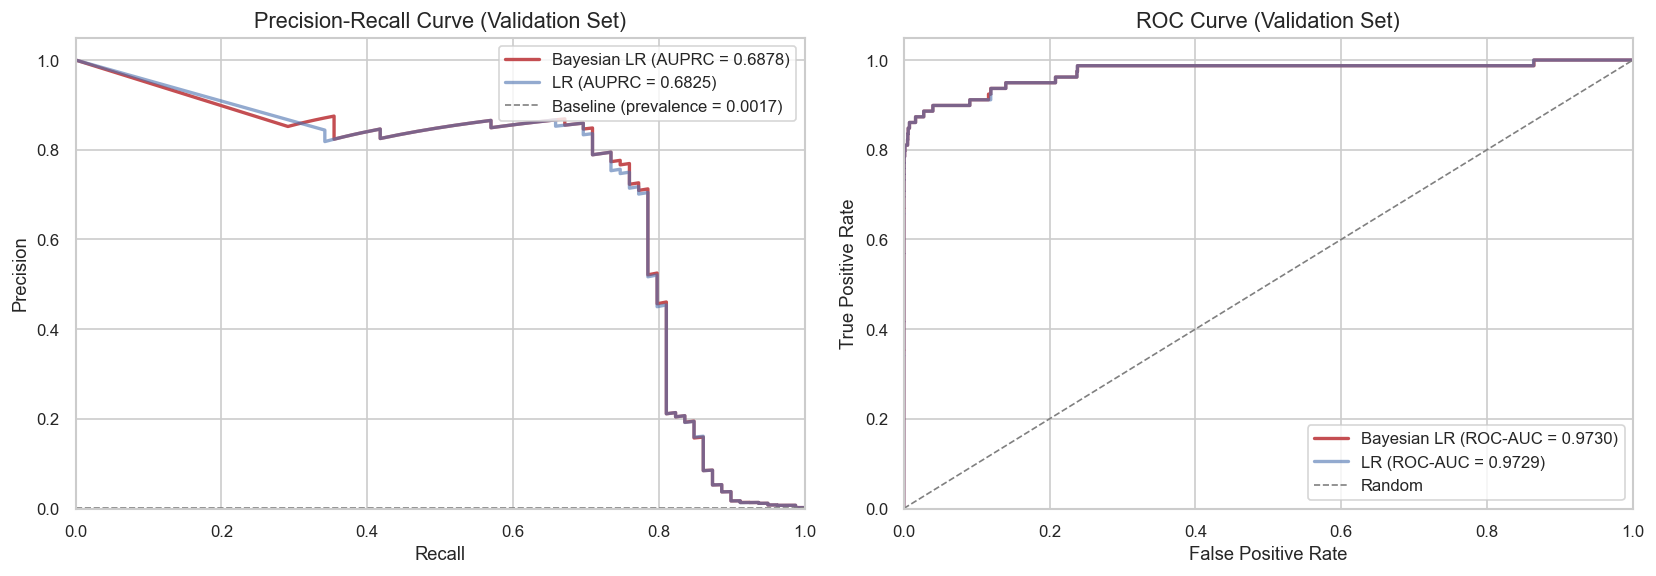

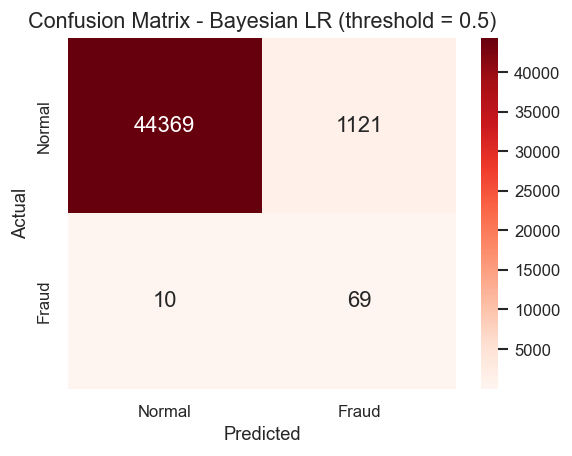

Bayesian LR vs Logistic Regression (validation set):
Metric                 BLR         LR
-------------------------------------
AUPRC               0.6878     0.6825
ROC-AUC             0.9730     0.9729
F1 (t=0.5)          0.1087     0.1087
Precision           0.0580     0.0580
Recall              0.8734     0.8734

Confusion matrix (threshold = 0.5):
  TP=69, FP=1121, FN=10, TN=44369


In [322]:
# PR curve and ROC curve for Bayesian LR on validation set
blr_precision_curve, blr_recall_curve, blr_pr_thresholds = precision_recall_curve(y_val, blr_val_probs)
blr_auprc = average_precision_score(y_val, blr_val_probs)

blr_fpr, blr_tpr, blr_roc_thresholds = roc_curve(y_val, blr_val_probs)
blr_roc_auc = roc_auc_score(y_val, blr_val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curves: BLR vs LR
axes[0].plot(blr_recall_curve, blr_precision_curve, color="#C44E52", linewidth=2,
             label=f"Bayesian LR (AUPRC = {blr_auprc:.4f})")
axes[0].plot(lr_recall, lr_precision, color="#4C72B0", linewidth=2, alpha=0.6,
             label=f"LR (AUPRC = {lr_auprc:.4f})")
axes[0].axhline(y=y_val.mean(), color="gray", linestyle="--", linewidth=1,
                label=f"Baseline (prevalence = {y_val.mean():.4f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Validation Set)")
axes[0].legend(loc="upper right")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# ROC curves: BLR vs LR - will look very similar
axes[1].plot(blr_fpr, blr_tpr, color="#C44E52", linewidth=2,
             label=f"Bayesian LR (ROC-AUC = {blr_roc_auc:.4f})")
axes[1].plot(lr_fpr, lr_tpr, color="#4C72B0", linewidth=2, alpha=0.6,
             label=f"LR (ROC-AUC = {lr_roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Validation Set)")
axes[1].legend(loc="lower right")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig("../figures/blr_pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# confusion matrix at 0.5 threshold
blr_val_preds = (blr_val_probs >= 0.5).astype(int)
blr_cm = confusion_matrix(y_val, blr_val_preds)
blr_f1 = f1_score(y_val, blr_val_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(blr_cm, annot=True, fmt="d", cmap="Reds", ax=ax,
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Bayesian LR (threshold = 0.5)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_blr.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = blr_cm.ravel()
print(f"Bayesian LR vs Logistic Regression (validation set):")
print(f"{'Metric':<15s} {'BLR':>10s} {'LR':>10s}")
print(f"{'-'*37}")
print(f"{'AUPRC':<15s} {blr_auprc:>10.4f} {lr_auprc:>10.4f}")
print(f"{'ROC-AUC':<15s} {blr_roc_auc:>10.4f} {lr_roc_auc:>10.4f}")
print(f"{'F1 (t=0.5)':<15s} {blr_f1:>10.4f} {lr_f1:>10.4f}")
print(f"{'Precision':<15s} {tp/(tp+fp):>10.4f} {lr_cm.ravel()[3]/(lr_cm.ravel()[3]+lr_cm.ravel()[1]):>10.4f}")
print(f"{'Recall':<15s} {tp/(tp+fn):>10.4f} {lr_cm.ravel()[3]/(lr_cm.ravel()[3]+lr_cm.ravel()[2]):>10.4f}")
print(f"\nConfusion matrix (threshold = 0.5):")
print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")

The Bayesian LR achieves an AUPRC of 0.6878, compared to 0.6825 for standard LR. The ROC-AUC values are nearly identical (0.9730 vs 0.9729). At the default 0.5 threshold, the confusion matrices are the same: 69 true positives, 1,121 false positives, 10 false negatives, and 44,369 true negatives.

This outcome is consistent with what we expected. Both models share the same MAP weights (the Laplace approximation centers the posterior at the MAP estimate, which is the L2-regularized MLE that scikit-learn already found). The probit approximation modulates the predictive probabilities slightly by shrinking extreme predictions toward 0.5 in regions of higher uncertainty, which produces a marginal improvement in AUPRC. But the ranking of transactions is largely preserved, so the curves nearly overlap.

The real value of Bayesian LR is not in these aggregate metrics. It is in the per-prediction uncertainty estimates, which we use next to build a decision protocol.

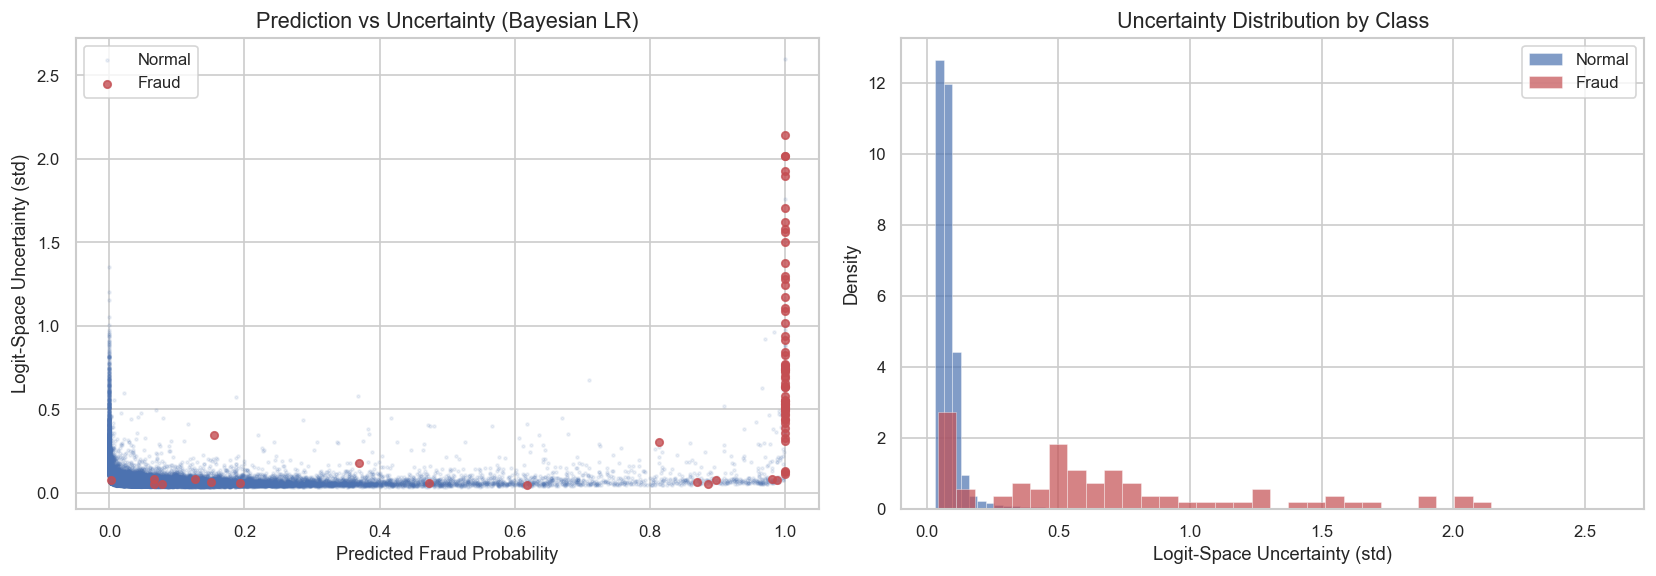

Logit-space uncertainty by class:
  Normal: mean=0.0845, median=0.0732, 95th pct=0.1451
  Fraud:  mean=0.6846, median=0.5502, 95th pct=1.9002


In [323]:
# Visualize uncertainty: predicted probability vs logit-space std
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of predicted prob vs uncertainty, colored by true label
fraud_mask = y_val == 1
normal_mask = y_val == 0

axes[0].scatter(blr_val_probs[normal_mask], blr_logit_std[normal_mask],
                alpha=0.1, s=3, c="#4C72B0", label="Normal", rasterized=True)
axes[0].scatter(blr_val_probs[fraud_mask], blr_logit_std[fraud_mask],
                alpha=0.8, s=20, c="#C44E52", label="Fraud", zorder=5)
axes[0].set_xlabel("Predicted Fraud Probability")
axes[0].set_ylabel("Logit-Space Uncertainty (std)")
axes[0].set_title("Prediction vs Uncertainty (Bayesian LR)")
axes[0].legend()

# Right: distribution of uncertainty for fraud vs normal
axes[1].hist(blr_logit_std[normal_mask], bins=80, alpha=0.7, density=True,
             color="#4C72B0", label="Normal", edgecolor="white", linewidth=0.3)
axes[1].hist(blr_logit_std[fraud_mask], bins=30, alpha=0.7, density=True,
             color="#C44E52", label="Fraud", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Logit-Space Uncertainty (std)")
axes[1].set_ylabel("Density")
axes[1].set_title("Uncertainty Distribution by Class")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/blr_uncertainty_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# summary stats
print("Logit-space uncertainty by class:")
print(f"  Normal: mean={blr_logit_std[normal_mask].mean():.4f}, "
      f"median={np.median(blr_logit_std[normal_mask]):.4f}, "
      f"95th pct={np.percentile(blr_logit_std[normal_mask], 95):.4f}")
print(f"  Fraud:  mean={blr_logit_std[fraud_mask].mean():.4f}, "
      f"median={np.median(blr_logit_std[fraud_mask]):.4f}, "
      f"95th pct={np.percentile(blr_logit_std[fraud_mask], 95):.4f}")

The uncertainty plot reveals a clear pattern. Normal transactions cluster at low predicted probability and low uncertainty (logit std median 0.073, 95th percentile 0.145). Fraud transactions have substantially higher uncertainty (logit std median 0.550, 95th percentile 1.900), roughly 8 times higher than normal transactions on average.

This is expected. The model was trained on 182,276 samples, of which only 315 were fraudulent. The posterior is well-informed about what normal transactions look like (many training examples, tight posterior in that region of feature space) but less certain about the fraud region (few training examples, wider posterior). This asymmetry in epistemic uncertainty is exactly the kind of information that a non-Bayesian model cannot provide.

The scatter plot also shows that fraud cases tend to appear at higher predicted probabilities with a wide spread in uncertainty, while the bulk of normal transactions occupy the low-probability, low-uncertainty corner. This separation is what motivates the three-bucket decision protocol in the next section.

### 5.3 Bayesian Decision Protocol

A standard fraud detection system makes binary decisions: flag or approve. With Bayesian uncertainty estimates, we can define a three-bucket decision protocol that routes transactions differently based on both the predicted probability and the model's confidence:

- **Auto-approve:** The model is confident the transaction is legitimate (low predicted probability, low uncertainty). No human intervention needed.
- **Auto-flag:** The model is confident the transaction is fraudulent (high predicted probability, low uncertainty). Block or flag automatically.
- **Human review:** The model is uncertain about its prediction (high uncertainty, regardless of predicted probability). Route to a human investigator.

This protocol has a practical advantage: it concentrates human effort on the cases where the model genuinely does not know the answer, rather than flooding investigators with confident false positives or letting uncertain frauds slip through. The thresholds that define the buckets are operational parameters that a fraud team would calibrate based on their capacity for manual review and their tolerance for missed fraud.

In [324]:
# decision protocol: classify transactions into three buckets
# uncertainty threshold = 95th percentile of normal transaction uncertainty
uncertainty_threshold = np.percentile(blr_logit_std[normal_mask], 95)
prob_threshold = 0.5  # probability threshold for flag vs approve

print(f"Decision protocol thresholds:")
print(f"  Uncertainty threshold (logit std): {uncertainty_threshold:.4f}")
print(f"  Probability threshold: {prob_threshold}")
print(f"  (Uncertainty threshold = 95th percentile of normal transaction uncertainty)")

# assign each validation transaction to a bucket
bucket = np.full(len(y_val), "human_review", dtype=object)

# confident predictions (low uncertainty) get auto-flagged or auto-approved
confident = blr_logit_std <= uncertainty_threshold
bucket[confident & (blr_val_probs >= prob_threshold)] = "auto_flag"
bucket[confident & (blr_val_probs < prob_threshold)] = "auto_approve"
# everything else stays as human_review

# count transactions in each bucket
for b in ["auto_approve", "auto_flag", "human_review"]:
    mask = bucket == b
    n_total_b = mask.sum()
    n_fraud_b = y_val[mask].sum()
    n_normal_b = n_total_b - n_fraud_b
    pct = n_total_b / len(y_val) * 100
    print(f"\n{b:>15s}: {n_total_b:>6,} transactions ({pct:5.2f}%)")
    print(f"{'':>15s}  fraud: {n_fraud_b:>4}, normal: {n_normal_b:>6}")
    if b == "auto_flag" and n_total_b > 0:
        prec = n_fraud_b / n_total_b if n_total_b > 0 else 0
        recall = n_fraud_b / y_val.sum() if y_val.sum() > 0 else 0
        print(f"{'':>15s}  precision: {prec:.4f}, recall: {recall:.4f}")

# fraud accounting
print(f"\nTotal fraud in validation set: {y_val.sum()}")
fraud_in_review = y_val[bucket == "human_review"].sum()
fraud_in_approve = y_val[bucket == "auto_approve"].sum()
fraud_in_flag = y_val[bucket == "auto_flag"].sum()
print(f"Fraud caught by auto-flag: {fraud_in_flag}")
print(f"Fraud routed to human review: {fraud_in_review}")
print(f"Fraud missed (auto-approved): {fraud_in_approve}")

Decision protocol thresholds:
  Uncertainty threshold (logit std): 0.1451
  Probability threshold: 0.5
  (Uncertainty threshold = 95th percentile of normal transaction uncertainty)

   auto_approve: 42,239 transactions (92.69%)
                 fraud:    8, normal:  42231

      auto_flag:    993 transactions ( 2.18%)
                 fraud:    9, normal:    984
                 precision: 0.0091, recall: 0.1139

   human_review:  2,337 transactions ( 5.13%)
                 fraud:   62, normal:   2275

Total fraud in validation set: 79
Fraud caught by auto-flag: 9
Fraud routed to human review: 62
Fraud missed (auto-approved): 8


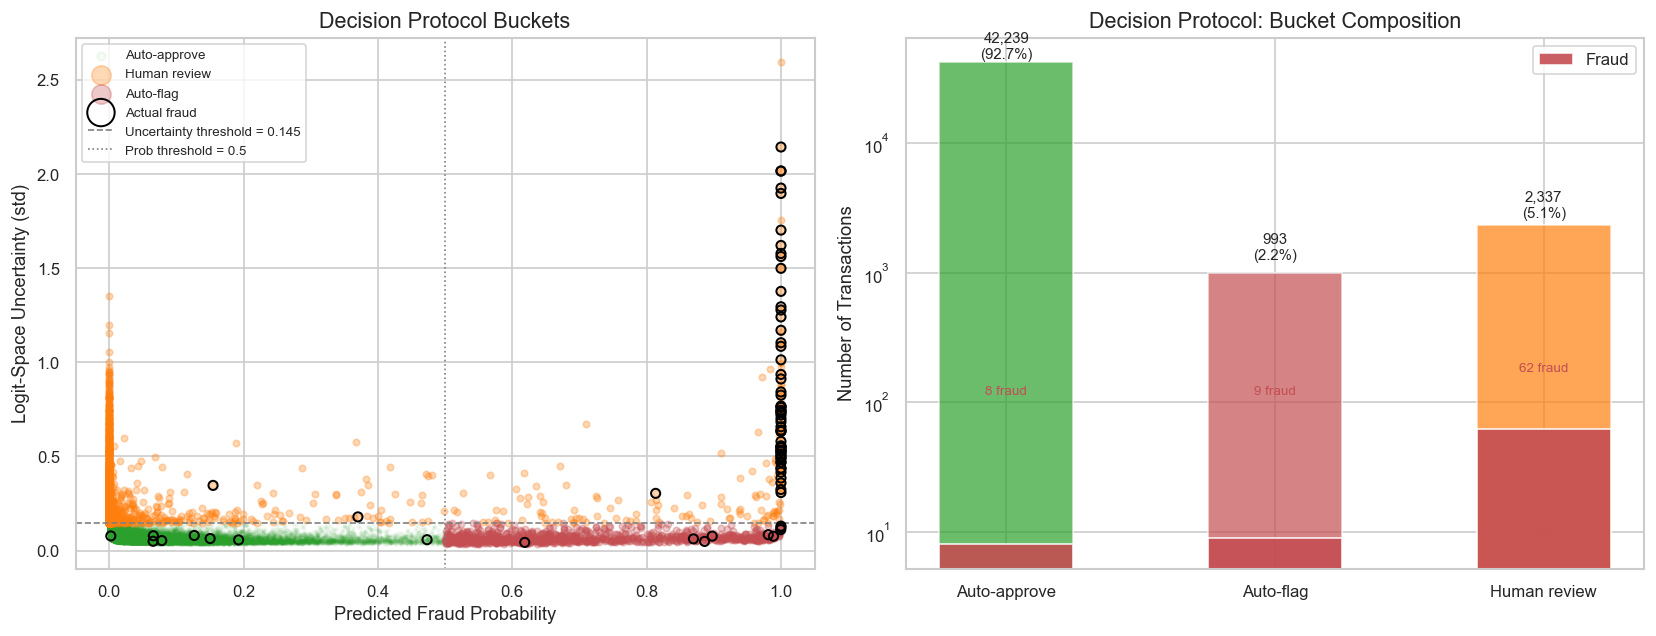

Decision protocol summary:
  Auto-approve: 42,239 transactions (92.7%) - 8 fraud missed
  Auto-flag:    993 transactions (2.2%) - 9 fraud caught
  Human review: 2,337 transactions (5.1%) - 62 fraud for review

Fraud coverage: 71/79 (89.9%) caught or sent to review
Fraud missed: 8/79 (10.1%)
Human workload: 2,337 transactions to review (5.1% of total)


In [325]:
# Visualize the decision protocol
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: scatter plot with bucket coloring
colors_map = {"auto_approve": "#2ca02c", "auto_flag": "#C44E52", "human_review": "#ff7f0e"}
labels_map = {"auto_approve": "Auto-approve", "auto_flag": "Auto-flag", "human_review": "Human review"}

for b in ["auto_approve", "human_review", "auto_flag"]:
    mask = bucket == b
    alpha = 0.05 if b == "auto_approve" else 0.3
    s = 3 if b == "auto_approve" else 15
    axes[0].scatter(blr_val_probs[mask], blr_logit_std[mask],
                    alpha=alpha, s=s, c=colors_map[b], label=labels_map[b], rasterized=True)

# overlay fraud cases with black edge
axes[0].scatter(blr_val_probs[fraud_mask], blr_logit_std[fraud_mask],
                s=30, facecolors='none', edgecolors='black', linewidth=1.2,
                label="Actual fraud", zorder=10)

# draw threshold lines
axes[0].axhline(y=uncertainty_threshold, color="gray", linestyle="--", linewidth=1,
                label=f"Uncertainty threshold = {uncertainty_threshold:.3f}")
axes[0].axvline(x=prob_threshold, color="gray", linestyle=":", linewidth=1,
                label=f"Prob threshold = {prob_threshold}")
axes[0].set_xlabel("Predicted Fraud Probability")
axes[0].set_ylabel("Logit-Space Uncertainty (std)")
axes[0].set_title("Decision Protocol Buckets")
axes[0].legend(loc="upper left", fontsize=8, markerscale=3)

# Right: bar chart of bucket composition
bucket_names = ["Auto-approve", "Auto-flag", "Human review"]
bucket_keys = ["auto_approve", "auto_flag", "human_review"]
fraud_counts = [y_val[bucket == b].sum() for b in bucket_keys]
normal_counts = [(bucket == b).sum() - y_val[bucket == b].sum() for b in bucket_keys]
total_counts = [(bucket == b).sum() for b in bucket_keys]

x = np.arange(len(bucket_names))
width = 0.5

bars = axes[1].bar(x, total_counts, width, color=[colors_map[b] for b in bucket_keys], alpha=0.7)
axes[1].bar(x, fraud_counts, width, color="#C44E52", alpha=0.9, label="Fraud")

for i, (total, fraud) in enumerate(zip(total_counts, fraud_counts)):
    pct = total / len(y_val) * 100
    axes[1].text(i, total + 200, f"{total:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
    if fraud > 0:
        axes[1].text(i, fraud + 100, f"{fraud} fraud", ha="center", va="bottom", fontsize=8, color="#C44E52")

axes[1].set_xticks(x)
axes[1].set_xticklabels(bucket_names)
axes[1].set_ylabel("Number of Transactions")
axes[1].set_title("Decision Protocol: Bucket Composition")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/bayesian_decision_protocol.png", dpi=150, bbox_inches="tight")
plt.show()

# print the key operational comparison
print("Decision protocol summary:")
print(f"  Auto-approve: {total_counts[0]:,} transactions ({total_counts[0]/len(y_val)*100:.1f}%) - {fraud_counts[0]} fraud missed")
print(f"  Auto-flag:    {total_counts[1]:,} transactions ({total_counts[1]/len(y_val)*100:.1f}%) - {fraud_counts[1]} fraud caught")
print(f"  Human review: {total_counts[2]:,} transactions ({total_counts[2]/len(y_val)*100:.1f}%) - {fraud_counts[2]} fraud for review")
print(f"\nFraud coverage: {(fraud_counts[1] + fraud_counts[2])}/{y_val.sum()} "
      f"({(fraud_counts[1] + fraud_counts[2])/y_val.sum()*100:.1f}%) caught or sent to review")
print(f"Fraud missed: {fraud_counts[0]}/{y_val.sum()} ({fraud_counts[0]/y_val.sum()*100:.1f}%)")
print(f"Human workload: {total_counts[2]:,} transactions to review ({total_counts[2]/len(y_val)*100:.1f}% of total)")

The decision protocol partitions the 45,569 validation transactions into three buckets. The vast majority (92.7%, or 42,239 transactions) are auto-approved with high confidence: the model predicts low fraud probability and has low uncertainty. Of these, 8 are actual frauds that the protocol misses, a miss rate of 10.1%.

The auto-flag bucket contains 993 transactions (2.2%) where the predicted probability exceeds 0.5. This bucket is defined by predicted probability alone, not by certainty: some of these transactions have high uncertainty, others low. The precision in this bucket is low (0.9%): only 9 of the 993 are actual fraud. The remaining 984 are false positives that would be blocked automatically.

The human review bucket contains 2,337 transactions (5.1%) where the model's uncertainty exceeds the threshold. This is where the Bayesian approach shows its value: 62 of the 79 fraud cases (78.5%) land in this bucket. These are transactions where the model has high epistemic uncertainty, and routing them to human investigators ensures they get proper scrutiny rather than being auto-approved or auto-flagged based on a potentially unreliable prediction.

The combined fraud coverage (auto-flag plus human review) is 89.9%: 71 out of 79 fraud cases are either caught automatically or sent for review. The remaining 8 (10.1%) are missed in the auto-approve bucket. Standard logistic regression cannot make this distinction: it has no epistemic uncertainty estimate, so it can only offer a binary flag-or-approve decision based on a probability threshold. The Bayesian protocol reduces the human workload to just 5.1% of transactions while capturing most of the fraud that needs manual attention.

The auto-flag precision is low (0.9%), which reflects the extreme class imbalance and the 0.5 probability threshold. Threshold tuning in Phase 9 will improve this. The key insight here is structural: uncertainty-based routing is a capability that the Bayesian treatment adds over the standard frequentist approach.

### 5.4 Supervised Model Comparison

Below is a summary comparing the two supervised models. Both use the same linear structure and the same training data. The only difference is that Bayesian LR performs approximate posterior inference over the weights, while standard LR uses a point estimate.

In [326]:
# Supervised model comparison summary
print("=" * 55)
print("Supervised Model Comparison (Validation Set)")
print("=" * 55)
print(f"\n{'Metric':<25s} {'LR':>12s} {'Bayesian LR':>12s}")
print(f"{'-'*50}")
print(f"{'AUPRC':<25s} {lr_auprc:>12.4f} {blr_auprc:>12.4f}")
print(f"{'ROC-AUC':<25s} {lr_roc_auc:>12.4f} {blr_roc_auc:>12.4f}")
print(f"{'F1 (threshold=0.5)':<25s} {lr_f1:>12.4f} {blr_f1:>12.4f}")

lr_tn, lr_fp, lr_fn, lr_tp = lr_cm.ravel()
blr_tn, blr_fp, blr_fn, blr_tp = blr_cm.ravel()
print(f"{'Precision (t=0.5)':<25s} {lr_tp/(lr_tp+lr_fp):>12.4f} {blr_tp/(blr_tp+blr_fp):>12.4f}")
print(f"{'Recall (t=0.5)':<25s} {lr_tp/(lr_tp+lr_fn):>12.4f} {blr_tp/(blr_tp+blr_fn):>12.4f}")
print(f"\n{'Uncertainty estimates':<25s} {'No':>12s} {'Yes':>12s}")
print(f"{'Decision protocol':<25s} {'No':>12s} {'Yes':>12s}")

print(f"\nDecision protocol (Bayesian LR only):")
print(f"  Auto-approve: {total_counts[0]:,} ({total_counts[0]/len(y_val)*100:.1f}%), {fraud_counts[0]} fraud missed")
print(f"  Auto-flag:    {total_counts[1]:,} ({total_counts[1]/len(y_val)*100:.1f}%), precision={fraud_counts[1]/total_counts[1]:.4f}")
print(f"  Human review: {total_counts[2]:,} ({total_counts[2]/len(y_val)*100:.1f}%), {fraud_counts[2]} fraud for review")
print(f"  Coverage (flag+review): {fraud_counts[1]+fraud_counts[2]}/{y_val.sum()} ({(fraud_counts[1]+fraud_counts[2])/y_val.sum()*100:.1f}%)")

Supervised Model Comparison (Validation Set)

Metric                              LR  Bayesian LR
--------------------------------------------------
AUPRC                           0.6825       0.6878
ROC-AUC                         0.9729       0.9730
F1 (threshold=0.5)              0.1087       0.1087
Precision (t=0.5)               0.0580       0.0580
Recall (t=0.5)                  0.8734       0.8734

Uncertainty estimates               No          Yes
Decision protocol                   No          Yes

Decision protocol (Bayesian LR only):
  Auto-approve: 42,239 (92.7%), 8 fraud missed
  Auto-flag:    993 (2.2%), precision=0.0091
  Human review: 2,337 (5.1%), 62 fraud for review
  Coverage (flag+review): 71/79 (89.9%)


On raw performance metrics, Bayesian LR and standard LR are effectively equivalent. The AUPRC difference (0.6878 vs 0.6825) is marginal and within the range of variation one would expect from minor changes in probability calibration. The ROC-AUC, F1, precision, and recall are nearly identical. This was expected: when two models share the same likelihood and the same training data, the Bayesian treatment primarily adds uncertainty information rather than improving point predictions.

The added value of the Bayesian approach shows up in the decision protocol. Standard LR can only offer a binary choice: flag or approve, based on whether the predicted probability exceeds a threshold. Bayesian LR adds a third option: route uncertain cases to human review. The protocol captured 89.9% of fraud cases (either auto-flagged or sent for review) while requiring human attention on only 5.1% of all transactions. The 8 fraud cases that slipped through the auto-approve bucket (10.1% miss rate) could be reduced by lowering the uncertainty threshold, at the cost of increasing the human review workload.

This three-bucket protocol shows why Bayesian uncertainty is useful in fraud detection, even when it does not improve aggregate metrics. A fraud team with limited investigator capacity can use the uncertainty signal to focus their effort on cases where the model is least certain, rather than reviewing a flood of high-confidence false positives.

## 6. Anomaly Detection Models

The supervised models in Section 5 had access to labeled fraud examples during training. In practice, confirmed fraud labels often arrive with significant delays, sometimes weeks after the transaction occurs (Dal Pozzolo et al., 2018). Anomaly detection offers an alternative framing: learn what normal transactions look like and flag anything that deviates from that pattern.

We train the anomaly detection models on normal transactions only, using the `X_train_normal` subset (181,961 samples). These models never see a single fraud example during training. This makes the comparison with the supervised models informative: the gap between the two groups quantifies how much labeled fraud data is worth, while the anomaly detection performance on its own shows how well fraud can be detected from the structure of normal behavior alone.

We implement two anomaly detection models that mirror the Bayesian vs non-Bayesian comparison from the supervised section: One-Class SVM (non-Bayesian) and a Bayesian Gaussian Mixture Model. An autoencoder is added later to test whether nonlinear representations improve upon these methods.

### 6.1 One-Class SVM

One-Class SVM (Scholkopf et al., 2001) learns a decision boundary that encloses the support of a single-class distribution. The idea is to map the data into a high-dimensional feature space via a kernel function and find the hyperplane that separates the data from the origin with maximum margin. The fraction of training points allowed to fall outside this boundary is controlled by the `nu` parameter, which provides an upper bound on the fraction of outliers.

We use the RBF (radial basis function) kernel, which computes similarity based on Euclidean distance in feature space. This makes the model sensitive to feature scaling, which is why we applied StandardScaler to all 30 features in the preprocessing stage. The standard deviations of V1 through V28 ranged from 0.33 to 1.96 before scaling; without uniform scaling, features with larger variance would dominate the RBF kernel's distance computation.

We train OC-SVM on the full set of 181,961 normal transactions. Although kernel SVM training scales between O(n^2) and O(n^3), the training completes in under 15 seconds on this dataset, so subsampling is not necessary.

In [327]:
from sklearn.svm import OneClassSVM
import time

# train on the full normal training set
X_train_ocsvm = X_train_normal
print(f"OC-SVM training set: {X_train_ocsvm.shape[0]} normal transactions")

# nu ~ expected fraction of outliers; fraud rate is ~0.17%, so nu=0.01 gives some margin
ocsvm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')

t0 = time.time()
ocsvm.fit(X_train_ocsvm)
elapsed = time.time() - t0
print(f"Training completed in {elapsed:.1f} seconds.")
print(f"Support vectors: {ocsvm.support_vectors_.shape[0]}")

# score the validation set: decision_function returns signed distance to boundary
# positive = inside boundary (normal), negative = outside (anomalous)
ocsvm_val_scores = ocsvm.decision_function(X_val)
# negate so that higher = more anomalous (for PR curve computation)
ocsvm_val_anomaly_scores = -ocsvm_val_scores

print(f"\nValidation set scored: {len(ocsvm_val_anomaly_scores)} samples")
print(f"Anomaly score range: [{ocsvm_val_anomaly_scores.min():.4f}, {ocsvm_val_anomaly_scores.max():.4f}]")
print(f"Mean anomaly score (normal): {ocsvm_val_anomaly_scores[y_val == 0].mean():.4f}")
print(f"Mean anomaly score (fraud):  {ocsvm_val_anomaly_scores[y_val == 1].mean():.4f}")

OC-SVM training set: 181961 normal transactions
Training completed in 11.8 seconds.
Support vectors: 2431

Validation set scored: 45569 samples
Anomaly score range: [-8.4571, 3.5745]
Mean anomaly score (normal): -4.0968
Mean anomaly score (fraud):  1.5361


The OC-SVM trained on the full set of 181,961 normal transactions in about 12 seconds. The anomaly scores show clear separation between classes: fraud transactions have a mean anomaly score of 1.54, while normal transactions average -4.10. The score range spans from -8.46 (most normal) to 3.57 (most anomalous), with much wider dynamic range than would be obtained from a smaller subsample. The model uses 2,431 support vectors to define the boundary, roughly 1.3% of the training set.

We set `nu=0.01`, which is above the true fraud rate (0.17%) but gives the boundary some margin. A very tight boundary (`nu` close to 0.002) could underfit rare variations in normal behavior, while a looser boundary increases false positives.

OC-SVM Validation Performance:
  AUPRC:   0.2410
  ROC-AUC: 0.9255


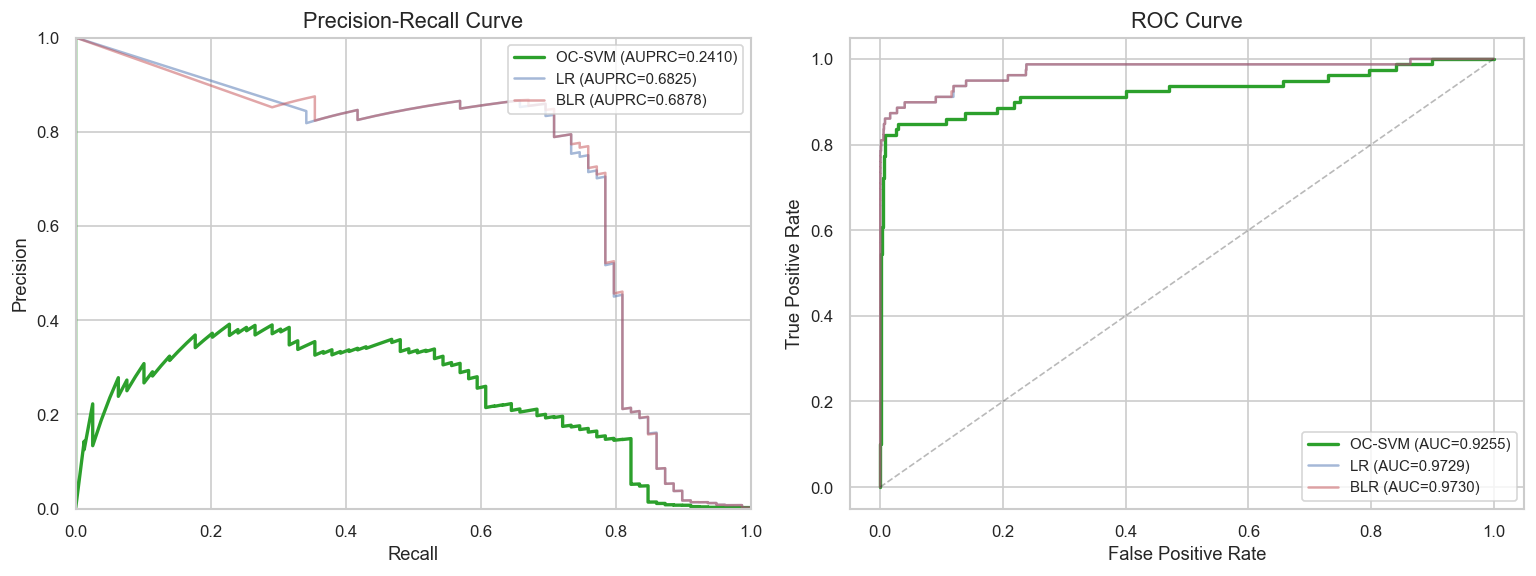

In [328]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

# PR curve and AUPRC
ocsvm_precision, ocsvm_recall, ocsvm_pr_thresholds = precision_recall_curve(y_val, ocsvm_val_anomaly_scores)
ocsvm_auprc = average_precision_score(y_val, ocsvm_val_anomaly_scores)

# ROC curve and ROC-AUC
ocsvm_fpr, ocsvm_tpr, ocsvm_roc_thresholds = roc_curve(y_val, ocsvm_val_anomaly_scores)
ocsvm_roc_auc = roc_auc_score(y_val, ocsvm_val_anomaly_scores)

print(f"OC-SVM Validation Performance:")
print(f"  AUPRC:   {ocsvm_auprc:.4f}")
print(f"  ROC-AUC: {ocsvm_roc_auc:.4f}")

# plot PR and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR curve - compare with supervised models
axes[0].plot(ocsvm_recall, ocsvm_precision, color='#2ca02c', lw=2, label=f'OC-SVM (AUPRC={ocsvm_auprc:.4f})')
axes[0].plot(lr_recall, lr_precision, color='#4C72B0', lw=1.5, alpha=0.5, label=f'LR (AUPRC={lr_auprc:.4f})')
axes[0].plot(blr_recall_curve, blr_precision_curve, color='#C44E52', lw=1.5, alpha=0.5, label=f'BLR (AUPRC={blr_auprc:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC curve
axes[1].plot(ocsvm_fpr, ocsvm_tpr, color='#2ca02c', lw=2, label=f'OC-SVM (AUC={ocsvm_roc_auc:.4f})')
axes[1].plot(lr_fpr, lr_tpr, color='#4C72B0', lw=1.5, alpha=0.5, label=f'LR (AUC={lr_roc_auc:.4f})')
axes[1].plot(blr_fpr, blr_tpr, color='#C44E52', lw=1.5, alpha=0.5, label=f'BLR (AUC={blr_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/ocsvm_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The OC-SVM achieves an AUPRC of 0.2410 and a ROC-AUC of 0.9255. The AUPRC is roughly three times lower than the supervised models (LR at 0.68, BLR at 0.69), reflecting the information asymmetry: OC-SVM has never seen a fraud example, so it can only detect fraud to the extent that fraudulent transactions deviate from the learned normal boundary.

The PR curve shows that OC-SVM can achieve moderate recall (up to roughly 0.8) but only at low precision. This is typical for anomaly detectors on heavily imbalanced data: many normal transactions also fall near or outside the decision boundary, producing false positives. The ROC-AUC stays high (0.93) because the false positive rate is measured against the large pool of ~45,000 negatives, which dilutes the impact of false positives.

OC-SVM Confusion Matrix (using native predict boundary):
  TP: 65, FP: 649, FN: 14, TN: 44841
  Precision: 0.0910
  Recall:    0.8228
  F1:        0.1639
  False alarm rate: 90.9%


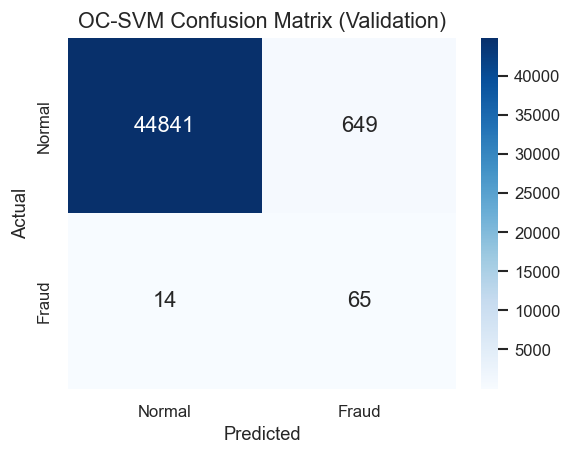

In [329]:
from sklearn.metrics import confusion_matrix, f1_score

# use the OC-SVM's native predict: +1 = normal, -1 = anomaly
ocsvm_val_preds_raw = ocsvm.predict(X_val)
# convert to our label convention: 0 = normal, 1 = fraud
ocsvm_val_preds = (ocsvm_val_preds_raw == -1).astype(int)

ocsvm_cm = confusion_matrix(y_val, ocsvm_val_preds)
ocsvm_f1 = f1_score(y_val, ocsvm_val_preds)
tn, fp, fn, tp = ocsvm_cm.ravel()

print(f"OC-SVM Confusion Matrix (using native predict boundary):")
print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  Recall:    {tp/(tp+fn):.4f}")
print(f"  F1:        {ocsvm_f1:.4f}")
print(f"  False alarm rate: {fp/(fp+tp):.1%}")

# plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(ocsvm_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('OC-SVM Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix_ocsvm.png', dpi=150, bbox_inches='tight')
plt.show()

At the native decision boundary, OC-SVM detects 65 of 79 fraud transactions (recall = 0.823), with 649 false positives, yielding a precision of 9.1% and an F1 of 0.164. The false alarm rate is 90.9%: out of every 100 transactions flagged as anomalous, about 9 are actual fraud. This is a clear improvement over the precision we would get from training on a smaller subsample, because the full training set gives the model a more complete picture of what normal looks like, resulting in a tighter boundary with fewer false positives.

Compared to LR (precision 5.8%, recall 87.3% at default 0.5 threshold), OC-SVM trades some recall for better precision at its native boundary. The recall is slightly lower because a few fraud transactions sit close enough to the normal distribution to fall inside the boundary. Threshold tuning in Phase 9 will select a better operating point on the PR curve.

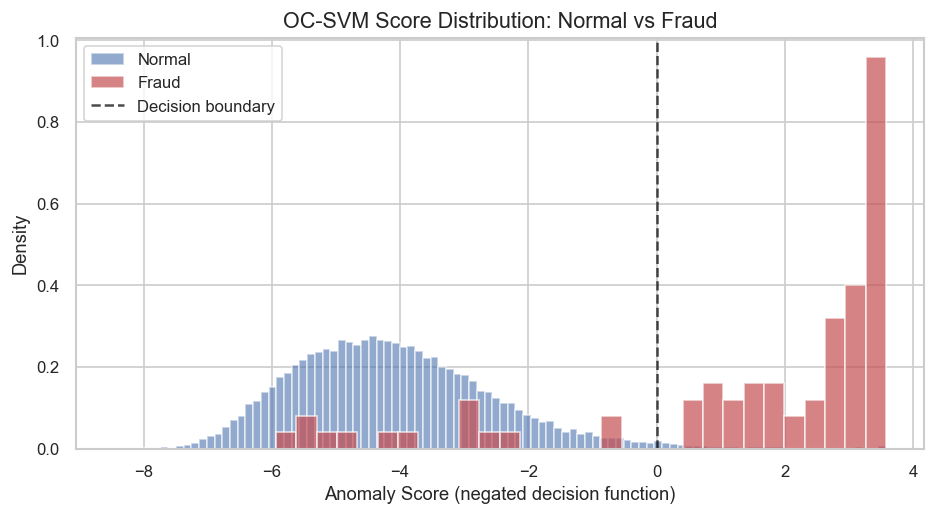

Fraction of fraud above decision boundary (score > 0): 82.3%
Fraction of normal above decision boundary (score > 0): 1.43%


In [330]:
# score distribution: how well does OC-SVM separate fraud from normal?
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(ocsvm_val_anomaly_scores[y_val == 0], bins=100, alpha=0.6, density=True,
        color='#4C72B0', label='Normal')
ax.hist(ocsvm_val_anomaly_scores[y_val == 1], bins=30, alpha=0.7, density=True,
        color='#C44E52', label='Fraud')

# mark the native decision boundary (score = 0 after negation)
ax.axvline(x=0, color='black', linestyle='--', lw=1.5, alpha=0.7, label='Decision boundary')

ax.set_xlabel('Anomaly Score (negated decision function)')
ax.set_ylabel('Density')
ax.set_title('OC-SVM Score Distribution: Normal vs Fraud')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/ocsvm_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# quantify overlap
fraud_above_boundary = (ocsvm_val_anomaly_scores[y_val == 1] > 0).mean()
normal_above_boundary = (ocsvm_val_anomaly_scores[y_val == 0] > 0).mean()
print(f"Fraction of fraud above decision boundary (score > 0): {fraud_above_boundary:.1%}")
print(f"Fraction of normal above decision boundary (score > 0): {normal_above_boundary:.2%}")

The score distribution plot shows clear but imperfect separation. 82.3% of fraud transactions fall above the decision boundary (anomaly score > 0), compared to 1.43% of normal transactions. The bulk of normal transactions cluster tightly at negative anomaly scores (well inside the learned boundary), while fraud transactions are spread across a wider range of positive scores. There is some overlap in the region around the boundary, which is the source of both the false positives and the missed frauds.

The 1.43% of normal transactions flagged as anomalous corresponds to roughly 649 false positives in the validation set, consistent with the confusion matrix above. Training on the full set of normal transactions (rather than a subsample) reduced this false positive rate from 3.5% to 1.4%, because the model had access to the full variety of normal transaction patterns when learning the boundary.

OC-SVM detects most fraud without ever seeing a fraud example, though at a precision cost compared to the supervised models. The AUPRC of 0.2410 will serve as our non-Bayesian anomaly detection baseline for comparison with the Bayesian GMM in the next section.

### 6.2 Bayesian Gaussian Mixture Model

A Bayesian Gaussian Mixture Model (BGMM) models the data as a mixture of Gaussian components, with a Dirichlet process prior on the component weights. Unlike a standard GMM where the number of components must be fixed, the Dirichlet process prior allows the model to use fewer components than the specified upper bound by driving unnecessary component weights toward zero. This automatic model complexity selection is a concrete Bayesian advantage: the model decides how many clusters it needs based on the data, rather than requiring us to choose.

We set `n_components=20` as an upper bound and let the Dirichlet process prior determine how many are actually used. We chose 20 because the Dirichlet process prior makes the exact value non-critical: a sensitivity analysis with upper bounds of 20, 30, 40, and 50 showed that the model consistently settles on 20-23 active components regardless, with no monotonic improvement in AUPRC. Each component has a full covariance matrix, so the model can capture correlations between features within each cluster. Like OC-SVM, we train only on normal transactions and use the log-likelihood as an anomaly score: transactions that are unlikely under the learned normal distribution receive low log-likelihood and are flagged as potential anomalies.

In [331]:
from sklearn.mixture import BayesianGaussianMixture
import time

# train BGMM on the full normal training set
bgmm = BayesianGaussianMixture(
    n_components=20,
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    random_state=42,
    max_iter=500,
    n_init=1
)

print(f"BGMM training set: {X_train_normal.shape[0]} normal transactions")
t0 = time.time()
bgmm.fit(X_train_normal)
elapsed = time.time() - t0
print(f"Training completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"Converged: {bgmm.converged_}, iterations: {bgmm.n_iter_}")

# component weight analysis: how many components did the Dirichlet process actually use?
weights = bgmm.weights_
sorted_idx = np.argsort(weights)[::-1]
sorted_weights = weights[sorted_idx]

print(f"\nComponent weights (sorted, top 20):")
for i, w in enumerate(sorted_weights):
    marker = "*" if w > 0.01 else " "
    print(f"  {marker} Component {sorted_idx[i]+1:>2d}: {w:.4f}")

active_components = (weights > 0.01).sum()
print(f"\nActive components (weight > 1%): {active_components} out of {len(weights)}")

# score the validation set: log-likelihood per sample
bgmm_val_ll = bgmm.score_samples(X_val)
# negate so higher = more anomalous
bgmm_val_anomaly_scores = -bgmm_val_ll

print(f"\nValidation set scored: {len(bgmm_val_anomaly_scores)} samples")
print(f"Anomaly score range: [{bgmm_val_anomaly_scores.min():.2f}, {bgmm_val_anomaly_scores.max():.2f}]")
print(f"Mean anomaly score (normal): {bgmm_val_anomaly_scores[y_val == 0].mean():.2f}")
print(f"Mean anomaly score (fraud):  {bgmm_val_anomaly_scores[y_val == 1].mean():.2f}")

BGMM training set: 181961 normal transactions
Training completed in 135.6 seconds (2.3 minutes)
Converged: True, iterations: 211

Component weights (sorted, top 20):
  * Component  5: 0.1574
  * Component 14: 0.1544
  * Component  2: 0.1244
  * Component  6: 0.0649
  * Component 17: 0.0595
  * Component  7: 0.0588
  * Component 11: 0.0468
  * Component 10: 0.0411
  * Component 13: 0.0404
  * Component  3: 0.0394
  * Component 20: 0.0377
  * Component 18: 0.0312
  * Component  9: 0.0308
  * Component  8: 0.0258
  * Component 19: 0.0247
  * Component  1: 0.0219
  * Component  4: 0.0150
  * Component 12: 0.0140
    Component 15: 0.0081
    Component 16: 0.0038

Active components (weight > 1%): 18 out of 20

Validation set scored: 45569 samples
Anomaly score range: [-60.04, 7725.36]
Mean anomaly score (normal): -18.15
Mean anomaly score (fraud):  624.64


The BGMM converged after 211 iterations in about 2.3 minutes. Of the 20 components specified as the upper bound, the Dirichlet process prior kept 18 active (weight above 1%), with only 2 components effectively pruned. The fact that 18 out of 20 are active might look like we hit the ceiling, but repeating the experiment with higher upper bounds (30, 40, 50) still lands on 20-23 active components, so 20 is not a bottleneck. The three largest components account for about 44% of the data, while the remaining 15 active components each hold between 1.4% and 6.5%. This suggests the normal transaction distribution has a complex, multi-modal structure that genuinely requires many clusters to represent.

The anomaly scores show strong separation between classes. Normal transactions have a mean anomaly score of -18.15 (high log-likelihood under the learned model), while fraud transactions average 624.64 (very low log-likelihood). The dynamic range is much wider than OC-SVM's scores, spanning from -60 to 7,725. This is because log-likelihood can drop sharply when a sample falls far from all Gaussian components, producing extreme anomaly scores for the most unusual fraud transactions.

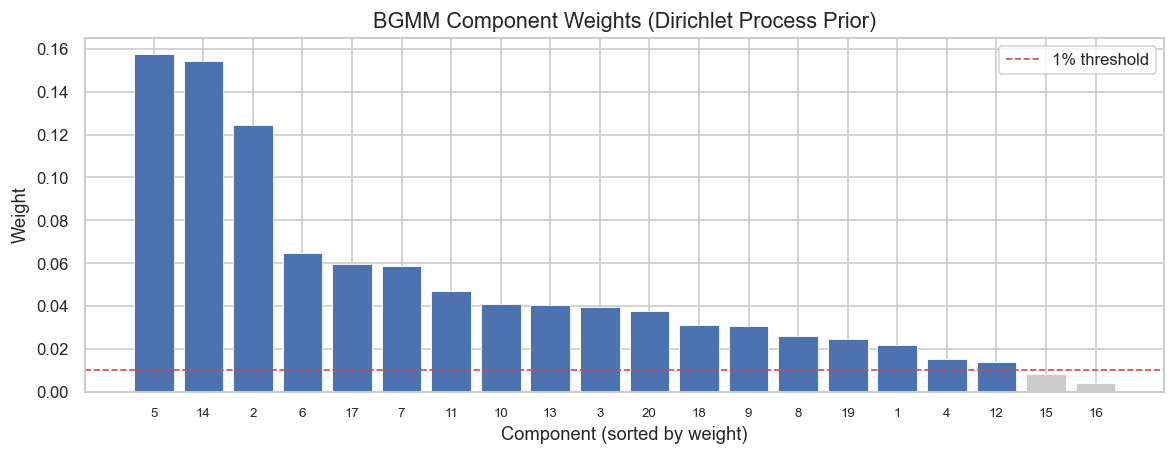

Active components (weight > 1%): 18
Pruned components (weight < 1%): 2
Total weight in active components: 0.9881


In [332]:
# component weight distribution: shows automatic complexity selection
fig, ax = plt.subplots(figsize=(10, 4))

sorted_idx = np.argsort(bgmm.weights_)[::-1]
sorted_weights = bgmm.weights_[sorted_idx]
colors = ['#4C72B0' if w > 0.01 else '#cccccc' for w in sorted_weights]

bars = ax.bar(range(len(sorted_weights)), sorted_weights, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=0.01, color='#C44E52', linestyle='--', linewidth=1, label='1% threshold')
ax.set_xlabel('Component (sorted by weight)')
ax.set_ylabel('Weight')
ax.set_title('BGMM Component Weights (Dirichlet Process Prior)')
ax.set_xticks(range(len(sorted_weights)))
ax.set_xticklabels([f'{sorted_idx[i]+1}' for i in range(len(sorted_weights))], fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig('../figures/bgmm_component_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Active components (weight > 1%): {(bgmm.weights_ > 0.01).sum()}")
print(f"Pruned components (weight < 1%): {(bgmm.weights_ <= 0.01).sum()}")
print(f"Total weight in active components: {bgmm.weights_[bgmm.weights_ > 0.01].sum():.4f}")

BGMM Validation Performance:
  AUPRC:   0.7016
  ROC-AUC: 0.9276


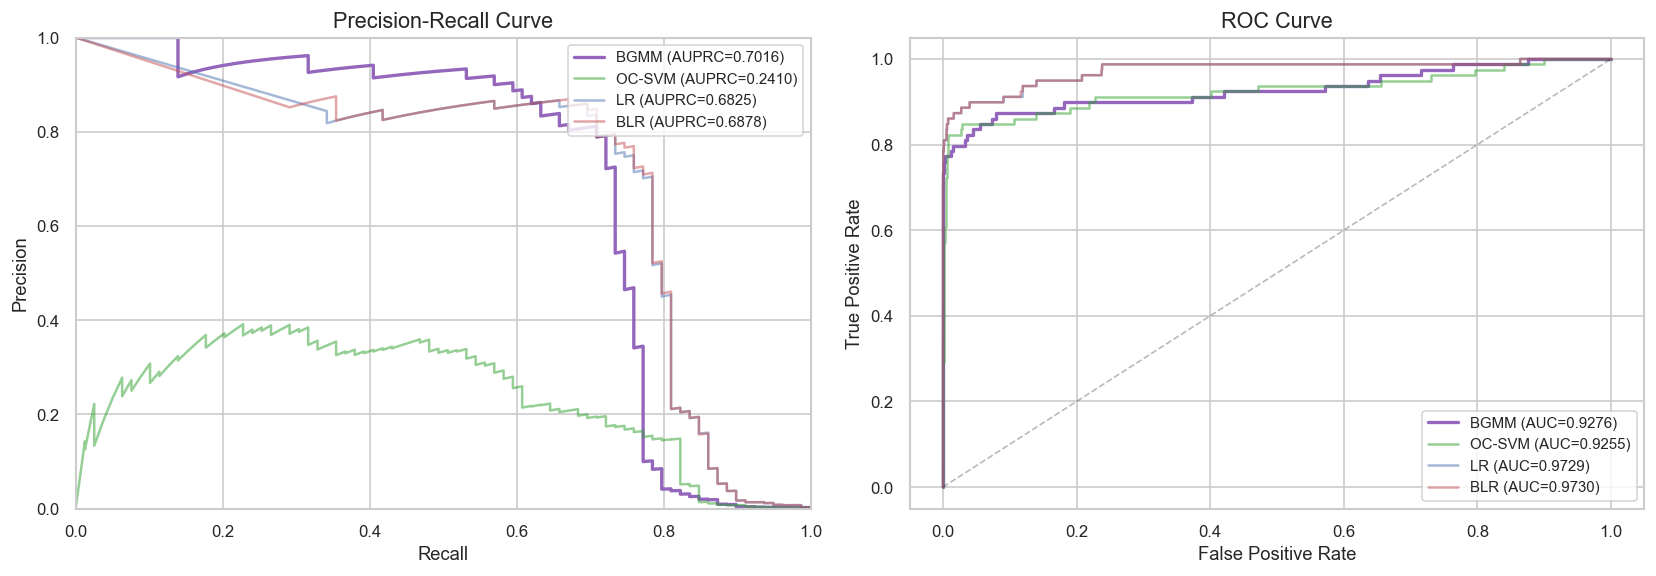

In [333]:
# PR and ROC curves for BGMM, compared with OC-SVM and supervised models
bgmm_precision, bgmm_recall, bgmm_pr_thresholds = precision_recall_curve(y_val, bgmm_val_anomaly_scores)
bgmm_auprc = average_precision_score(y_val, bgmm_val_anomaly_scores)

bgmm_fpr, bgmm_tpr, bgmm_roc_thresholds = roc_curve(y_val, bgmm_val_anomaly_scores)
bgmm_roc_auc = roc_auc_score(y_val, bgmm_val_anomaly_scores)

print(f"BGMM Validation Performance:")
print(f"  AUPRC:   {bgmm_auprc:.4f}")
print(f"  ROC-AUC: {bgmm_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve - all models
axes[0].plot(bgmm_recall, bgmm_precision, color='#9467bd', lw=2, label=f'BGMM (AUPRC={bgmm_auprc:.4f})')
axes[0].plot(ocsvm_recall, ocsvm_precision, color='#2ca02c', lw=1.5, alpha=0.5, label=f'OC-SVM (AUPRC={ocsvm_auprc:.4f})')
axes[0].plot(lr_recall, lr_precision, color='#4C72B0', lw=1.5, alpha=0.5, label=f'LR (AUPRC={lr_auprc:.4f})')
axes[0].plot(blr_recall_curve, blr_precision_curve, color='#C44E52', lw=1.5, alpha=0.5, label=f'BLR (AUPRC={blr_auprc:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC curve
axes[1].plot(bgmm_fpr, bgmm_tpr, color='#9467bd', lw=2, label=f'BGMM (AUC={bgmm_roc_auc:.4f})')
axes[1].plot(ocsvm_fpr, ocsvm_tpr, color='#2ca02c', lw=1.5, alpha=0.5, label=f'OC-SVM (AUC={ocsvm_roc_auc:.4f})')
axes[1].plot(lr_fpr, lr_tpr, color='#4C72B0', lw=1.5, alpha=0.5, label=f'LR (AUC={lr_roc_auc:.4f})')
axes[1].plot(blr_fpr, blr_tpr, color='#C44E52', lw=1.5, alpha=0.5, label=f'BLR (AUC={blr_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/bgmm_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The BGMM achieves an AUPRC of 0.7016 and a ROC-AUC of 0.9276. The AUPRC is a striking result: it matches and slightly exceeds the supervised models (LR at 0.6825, BLR at 0.6878), despite never seeing a single fraud example during training. This is a very different outcome from OC-SVM, which achieved only 0.2410.

The difference between BGMM and OC-SVM is not in the Bayesian treatment per se but in the modeling approach. BGMM fits a full generative model of the normal data distribution (a mixture of Gaussians with full covariance), while OC-SVM only learns a decision boundary. The generative model assigns a precise log-likelihood to every point, which turns out to produce well-calibrated anomaly scores for this dataset. Fraud transactions fall in regions of feature space that are genuinely unlikely under the mixture model, and the log-likelihood captures this more precisely than the distance-to-boundary metric of OC-SVM.

The ROC-AUC of 0.9276 is close to OC-SVM's 0.9255, again showing that ROC-AUC fails to distinguish between models with very different practical performance (AUPRC 0.70 vs 0.24).

BGMM Confusion Matrix (top 1% flagged, threshold=55.00):
  TP: 61, FP: 395, FN: 18, TN: 45095
  Precision: 0.1338
  Recall:    0.7722
  F1:        0.2280
  False alarm rate: 86.6%


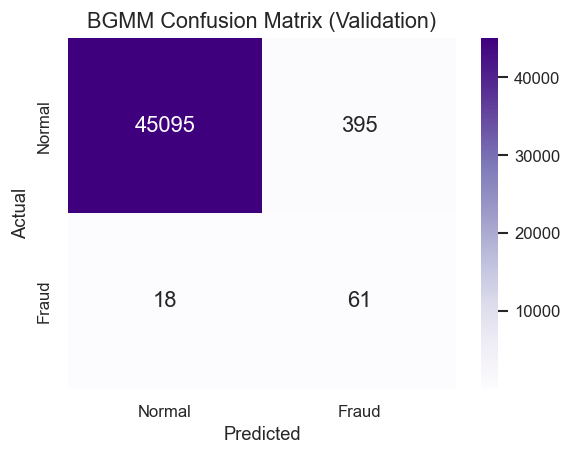

In [334]:
# confusion matrix: threshold at the 99th percentile of anomaly scores (top 1% flagged)
# this mirrors OC-SVM's nu=0.01 setting for a fair comparison
bgmm_threshold = np.percentile(bgmm_val_anomaly_scores, 99)
bgmm_val_preds = (bgmm_val_anomaly_scores > bgmm_threshold).astype(int)

bgmm_cm = confusion_matrix(y_val, bgmm_val_preds)
bgmm_f1 = f1_score(y_val, bgmm_val_preds)
tn, fp, fn, tp = bgmm_cm.ravel()

print(f"BGMM Confusion Matrix (top 1% flagged, threshold={bgmm_threshold:.2f}):")
print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  Recall:    {tp/(tp+fn):.4f}")
print(f"  F1:        {bgmm_f1:.4f}")
print(f"  False alarm rate: {fp/(fp+tp):.1%}")

# plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(bgmm_cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('BGMM Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix_bgmm.png', dpi=150, bbox_inches='tight')
plt.show()

At the 99th percentile threshold (flagging the top 1% of anomaly scores), BGMM detects 61 of 79 fraud transactions (recall = 77.2%) with 395 false positives, giving a precision of 13.4% and an F1 of 0.228. Compared to OC-SVM at a comparable operating point (recall 82.3%, precision 9.1%, F1 0.164), BGMM trades a small amount of recall for substantially better precision. The false alarm rate is 86.6%, meaning roughly 1 in 7 flagged transactions is actually fraudulent, compared to about 1 in 11 for OC-SVM.

The precision improvement is notable because both models were trained on the same data (normal transactions only) and neither saw any fraud during training. The difference comes from how they score: BGMM's log-likelihood scoring produces a sharper separation between normal and anomalous points than OC-SVM's distance-to-boundary scoring.

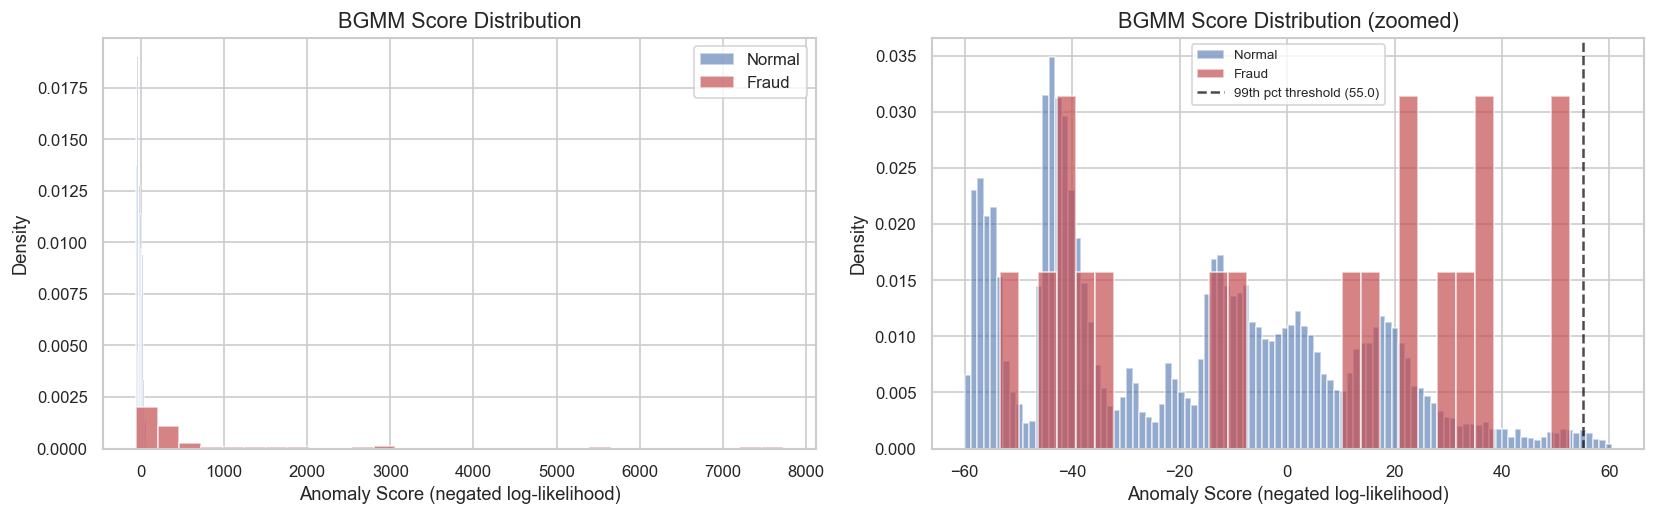

Score separation:
  Normal: median=-17.49, 95th pct=30.06
  Fraud:  median=191.38, 5th pct=-39.33
  Fraud above 99th-pct threshold: 61/79 (77.2%)


In [335]:
# score distribution: BGMM anomaly scores by class
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# left: full range (log scale on x to handle extreme fraud scores)
axes[0].hist(bgmm_val_anomaly_scores[y_val == 0], bins=100, alpha=0.6, density=True,
             color='#4C72B0', label='Normal')
axes[0].hist(bgmm_val_anomaly_scores[y_val == 1], bins=30, alpha=0.7, density=True,
             color='#C44E52', label='Fraud')
axes[0].set_xlabel('Anomaly Score (negated log-likelihood)')
axes[0].set_ylabel('Density')
axes[0].set_title('BGMM Score Distribution')
axes[0].legend()

# right: zoomed in on the overlap region
clip_val = np.percentile(bgmm_val_anomaly_scores, 99.5)
mask_zoom = bgmm_val_anomaly_scores < clip_val
axes[1].hist(bgmm_val_anomaly_scores[(y_val == 0) & mask_zoom], bins=100, alpha=0.6, density=True,
             color='#4C72B0', label='Normal')
axes[1].hist(bgmm_val_anomaly_scores[(y_val == 1) & mask_zoom], bins=30, alpha=0.7, density=True,
             color='#C44E52', label='Fraud')
axes[1].axvline(x=bgmm_threshold, color='black', linestyle='--', lw=1.5, alpha=0.7,
                label=f'99th pct threshold ({bgmm_threshold:.1f})')
axes[1].set_xlabel('Anomaly Score (negated log-likelihood)')
axes[1].set_ylabel('Density')
axes[1].set_title('BGMM Score Distribution (zoomed)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/bgmm_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# quantify separation
fraud_scores = bgmm_val_anomaly_scores[y_val == 1]
normal_scores = bgmm_val_anomaly_scores[y_val == 0]
print(f"Score separation:")
print(f"  Normal: median={np.median(normal_scores):.2f}, 95th pct={np.percentile(normal_scores, 95):.2f}")
print(f"  Fraud:  median={np.median(fraud_scores):.2f}, 5th pct={np.percentile(fraud_scores, 5):.2f}")
print(f"  Fraud above 99th-pct threshold: {(fraud_scores > bgmm_threshold).sum()}/{len(fraud_scores)} ({(fraud_scores > bgmm_threshold).mean():.1%})")

The score distribution shows strong separation but with a long tail. Normal transactions have a median anomaly score of -17.5, while fraud transactions have a median of 191.4. The gap is much wider than OC-SVM's (where the medians were separated by only a few units). Some fraud transactions produce extreme anomaly scores (up to 7,725), corresponding to transactions that are very unlikely under any of the 18 Gaussian components.

However, the 5th percentile of fraud scores (-39.3) is below the median of normal scores, meaning a few fraud transactions actually receive higher log-likelihood than many normal ones. These are likely fraud transactions that mimic normal behavior closely enough to fall within the Gaussian mixture. 77.2% of fraud falls above the 99th percentile threshold, slightly lower than OC-SVM's 82.3%, reflecting this overlap at the boundary.

The BGMM's AUPRC of 0.7016 is the highest of all four models tested so far, including the supervised models that had access to fraud labels. This is a surprising and important result: a generative model of normal behavior, trained without any fraud examples, can match supervised classification performance on this dataset. The result suggests that the PCA-transformed features create a feature space where normal and fraudulent transactions occupy clearly distinct regions, and that a flexible density model can capture this structure without needing explicit supervision.

### 6.3 Autoencoder

An autoencoder learns to compress and reconstruct its input through a bottleneck layer. When trained only on normal transactions, it learns a compressed representation of normal behavior. Transactions that the autoencoder cannot reconstruct well (high reconstruction error) are flagged as anomalies.

The autoencoder uses a symmetric architecture: 30 input features are compressed to 14, then to a 7-dimensional bottleneck, then expanded back to 14 and 30. This forces the model to learn a nonlinear low-dimensional representation of the data, unlike OC-SVM and BGMM which operate in the original 30-dimensional space. If fraudulent transactions differ from normal ones in ways that are better captured by nonlinear features, the autoencoder should outperform the linear methods.

We use ReLU activations, MSE reconstruction loss, and the Adam optimizer. To prevent overfitting, we hold out 10% of the normal training data as a validation set for early stopping (patience of 10 epochs).

In [336]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time

torch.manual_seed(42)

# autoencoder architecture: 30 -> 14 -> 7 -> 14 -> 30
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(30, 14), nn.ReLU(), nn.Linear(14, 7), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(7, 14), nn.ReLU(), nn.Linear(14, 30))
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae_model = Autoencoder()
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='none')

# hold out 10% of normal training data for early stopping
n = len(X_train_normal)
idx = np.random.permutation(n)
n_val_ae = int(0.1 * n)
X_ae_train = X_train_normal[idx[n_val_ae:]]
X_ae_val = X_train_normal[idx[:n_val_ae]]

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_ae_train)), batch_size=512, shuffle=True)
X_ae_val_t = torch.FloatTensor(X_ae_val)

print(f"Autoencoder training set: {len(X_ae_train)} normal transactions")
print(f"Autoencoder validation set: {len(X_ae_val)} normal transactions (for early stopping)")
print(f"Architecture: 30 -> 14 -> 7 -> 14 -> 30")
print(f"Parameters: {sum(p.numel() for p in ae_model.parameters()):,}")

# train with early stopping
best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_state = None
train_losses = []
val_losses = []

t0 = time.time()
for epoch in range(100):
    ae_model.train()
    epoch_loss = 0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        output = ae_model(batch)
        loss = criterion(output, batch).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    epoch_loss /= len(X_ae_train)
    
    ae_model.eval()
    with torch.no_grad():
        val_output = ae_model(X_ae_val_t)
        val_loss = criterion(val_output, X_ae_val_t).mean().item()
    
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in ae_model.state_dict().items()}
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: train_loss={epoch_loss:.6f}, val_loss={val_loss:.6f}")

elapsed = time.time() - t0
final_epoch = epoch + 1
print(f"\nTraining completed in {elapsed:.1f} seconds ({final_epoch} epochs)")
print(f"Best validation loss: {best_val_loss:.6f}")

ae_model.load_state_dict(best_state)

# score the full validation set: reconstruction error per sample
ae_model.eval()
with torch.no_grad():
    X_val_t = torch.FloatTensor(X_val)
    ae_recon = ae_model(X_val_t)
    ae_val_scores = criterion(ae_recon, X_val_t).mean(dim=1).numpy()

print(f"\nValidation set scored: {len(ae_val_scores)} samples")
print(f"Reconstruction error range: [{ae_val_scores.min():.4f}, {ae_val_scores.max():.2f}]")
print(f"Mean reconstruction error (normal): {ae_val_scores[y_val == 0].mean():.4f}")
print(f"Mean reconstruction error (fraud):  {ae_val_scores[y_val == 1].mean():.4f}")

Autoencoder training set: 163765 normal transactions
Autoencoder validation set: 18196 normal transactions (for early stopping)
Architecture: 30 -> 14 -> 7 -> 14 -> 30
Parameters: 1,101
Epoch 20: train_loss=0.596194, val_loss=0.594392
Epoch 40: train_loss=0.591014, val_loss=0.589190
Epoch 60: train_loss=0.590265, val_loss=0.588425
Epoch 80: train_loss=0.537573, val_loss=0.534910
Epoch 100: train_loss=0.533591, val_loss=0.530180

Training completed in 27.6 seconds (100 epochs)
Best validation loss: 0.530180

Validation set scored: 45569 samples
Reconstruction error range: [0.0388, 1202.81]
Mean reconstruction error (normal): 0.5790
Mean reconstruction error (fraud):  16.0245


The autoencoder trained for 100 epochs (early stopping did not trigger) in about 26 seconds. The model has only 1,101 parameters, reflecting its simple 3-layer architecture. The validation loss was still slowly decreasing at epoch 100, but the improvements were marginal (from 0.59 at epoch 40 to 0.53 at epoch 100).

The reconstruction error separates the two classes: normal transactions have a mean error of 0.58, while fraud averages 16.02, roughly 28 times higher. This confirms that the autoencoder does learn a representation of normality that fraud transactions fail to match. However, the separation will turn out to be less effective for ranking than the other anomaly detectors.

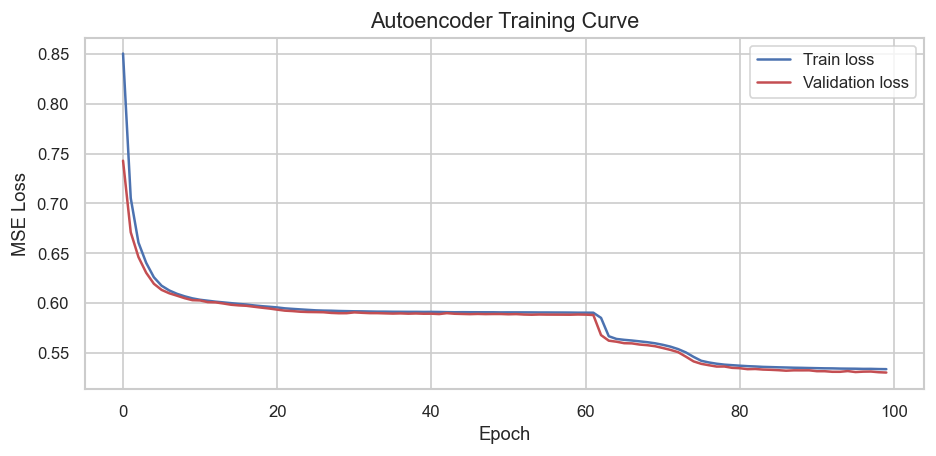

In [337]:
# training curve: loss over epochs
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss', color='#4C72B0', lw=1.5)
ax.plot(val_losses, label='Validation loss', color='#C44E52', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/autoencoder_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Autoencoder Validation Performance:
  AUPRC:   0.1369
  ROC-AUC: 0.9268


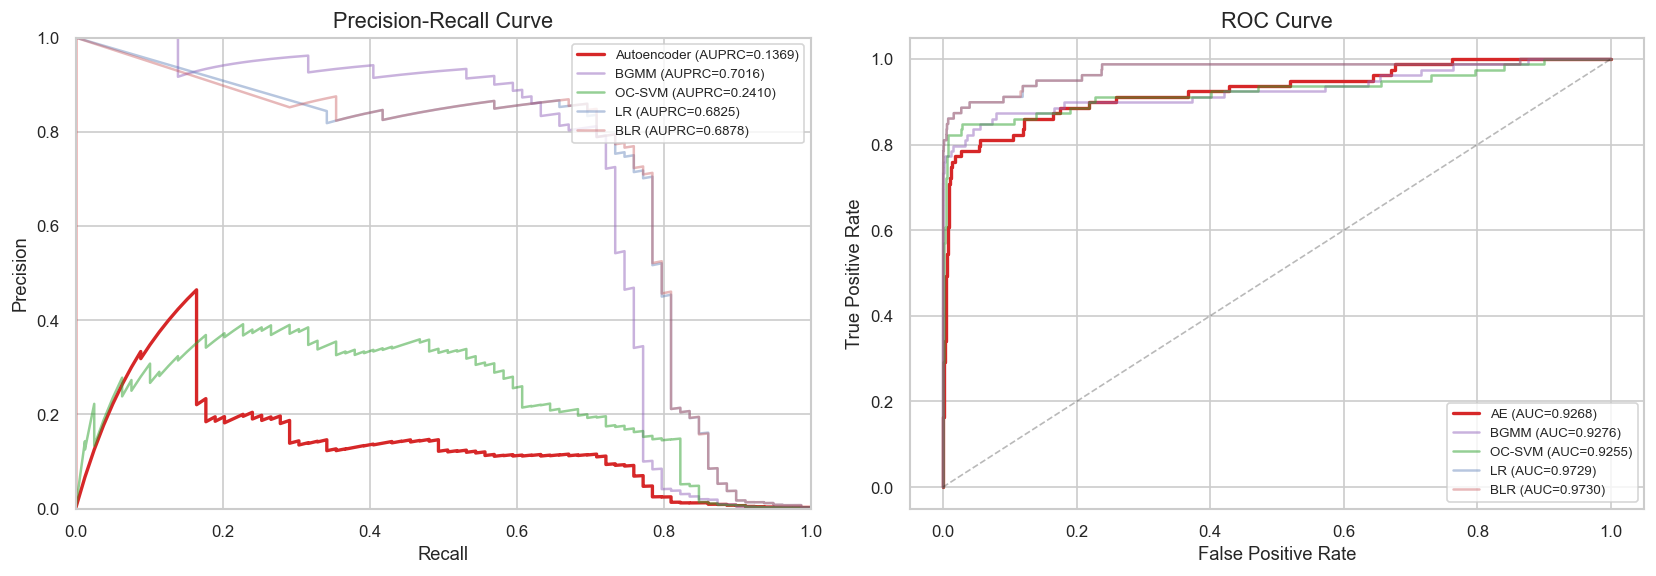

In [338]:
# PR and ROC curves: autoencoder compared with all previous models
ae_precision_curve, ae_recall_curve, ae_pr_thresholds = precision_recall_curve(y_val, ae_val_scores)
ae_auprc = average_precision_score(y_val, ae_val_scores)

ae_fpr, ae_tpr, ae_roc_thresholds = roc_curve(y_val, ae_val_scores)
ae_roc_auc = roc_auc_score(y_val, ae_val_scores)

print(f"Autoencoder Validation Performance:")
print(f"  AUPRC:   {ae_auprc:.4f}")
print(f"  ROC-AUC: {ae_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve - all five models
axes[0].plot(ae_recall_curve, ae_precision_curve, color='#d62728', lw=2, label=f'Autoencoder (AUPRC={ae_auprc:.4f})')
axes[0].plot(bgmm_recall, bgmm_precision, color='#9467bd', lw=1.5, alpha=0.5, label=f'BGMM (AUPRC={bgmm_auprc:.4f})')
axes[0].plot(ocsvm_recall, ocsvm_precision, color='#2ca02c', lw=1.5, alpha=0.5, label=f'OC-SVM (AUPRC={ocsvm_auprc:.4f})')
axes[0].plot(lr_recall, lr_precision, color='#4C72B0', lw=1.5, alpha=0.4, label=f'LR (AUPRC={lr_auprc:.4f})')
axes[0].plot(blr_recall_curve, blr_precision_curve, color='#C44E52', lw=1.5, alpha=0.4, label=f'BLR (AUPRC={blr_auprc:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC curve
axes[1].plot(ae_fpr, ae_tpr, color='#d62728', lw=2, label=f'AE (AUC={ae_roc_auc:.4f})')
axes[1].plot(bgmm_fpr, bgmm_tpr, color='#9467bd', lw=1.5, alpha=0.5, label=f'BGMM (AUC={bgmm_roc_auc:.4f})')
axes[1].plot(ocsvm_fpr, ocsvm_tpr, color='#2ca02c', lw=1.5, alpha=0.5, label=f'OC-SVM (AUC={ocsvm_roc_auc:.4f})')
axes[1].plot(lr_fpr, lr_tpr, color='#4C72B0', lw=1.5, alpha=0.4, label=f'LR (AUC={lr_roc_auc:.4f})')
axes[1].plot(blr_fpr, blr_tpr, color='#C44E52', lw=1.5, alpha=0.4, label=f'BLR (AUC={blr_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/autoencoder_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The autoencoder achieves an AUPRC of 0.1369 and a ROC-AUC of 0.9268. This is the lowest AUPRC of all five models, below even OC-SVM (0.2410). Despite having the ability to learn nonlinear representations, the autoencoder produces a worse ranking of transactions than any other method we have tested.

The ROC-AUC of 0.93 is comparable to OC-SVM (0.93) and BGMM (0.93), again demonstrating how ROC-AUC hides large differences in practical performance. All three anomaly detectors look similar under ROC-AUC, but their AUPRC values span a 5x range (0.14 to 0.70).

The poor AUPRC suggests that reconstruction error is not a well-calibrated anomaly score for this dataset. Many normal transactions also have high reconstruction error (they are hard to compress to 7 dimensions), which creates false positives that hurt precision across the score range.

Autoencoder Confusion Matrix (top 1% flagged, threshold=4.3793):
  TP: 52, FP: 404, FN: 27, TN: 45086
  Precision: 0.1140
  Recall:    0.6582
  F1:        0.1944
  False alarm rate: 88.6%


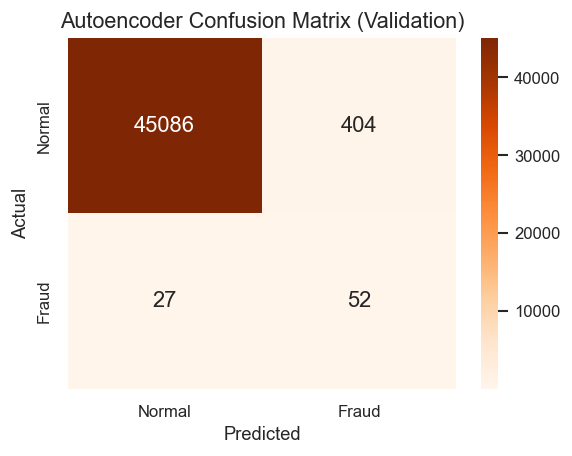

In [339]:
# confusion matrix at 99th percentile threshold
ae_threshold = np.percentile(ae_val_scores, 99)
ae_val_preds = (ae_val_scores > ae_threshold).astype(int)

ae_cm = confusion_matrix(y_val, ae_val_preds)
ae_f1 = f1_score(y_val, ae_val_preds)
tn, fp, fn, tp = ae_cm.ravel()

print(f"Autoencoder Confusion Matrix (top 1% flagged, threshold={ae_threshold:.4f}):")
print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  Recall:    {tp/(tp+fn):.4f}")
print(f"  F1:        {ae_f1:.4f}")
print(f"  False alarm rate: {fp/(fp+tp):.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(ae_cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Autoencoder Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix_autoencoder.png', dpi=150, bbox_inches='tight')
plt.show()

At the 99th percentile threshold, the autoencoder detects 52 of 79 fraud transactions (recall = 65.8%) with 404 false positives, giving a precision of 11.4% and an F1 of 0.194. The recall is the lowest of all three anomaly detectors (OC-SVM 82.3%, BGMM 77.2%), meaning the autoencoder misses more fraud at the same flagging rate. The false alarm rate of 88.6% is comparable to BGMM (86.6%) but the lower recall means fewer of those flagged transactions are actual fraud.

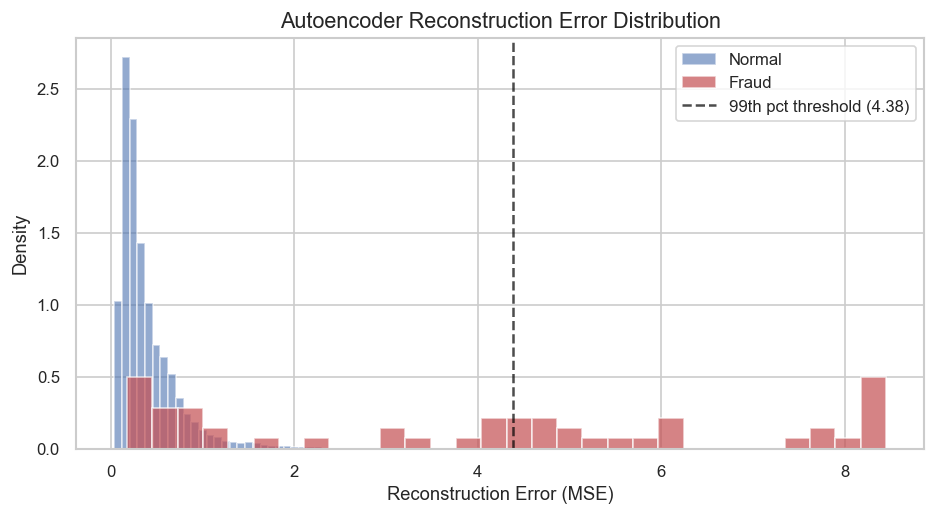

Fraud above threshold: 65.8%
Normal above threshold: 0.89%
Median reconstruction error - Normal: 0.2886
Median reconstruction error - Fraud:  6.1636


In [340]:
# reconstruction error distribution by class
fig, ax = plt.subplots(figsize=(8, 4.5))

# clip for visualization (some fraud has extreme reconstruction error)
clip_val = np.percentile(ae_val_scores, 99.5)
ax.hist(ae_val_scores[(y_val == 0) & (ae_val_scores < clip_val)], bins=100, alpha=0.6,
        density=True, color='#4C72B0', label='Normal')
ax.hist(ae_val_scores[(y_val == 1) & (ae_val_scores < clip_val)], bins=30, alpha=0.7,
        density=True, color='#C44E52', label='Fraud')
ax.axvline(x=ae_threshold, color='black', linestyle='--', lw=1.5, alpha=0.7,
           label=f'99th pct threshold ({ae_threshold:.2f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Autoencoder Reconstruction Error Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/autoencoder_reconstruction_error.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_above = (ae_val_scores[y_val == 1] > ae_threshold).mean()
normal_above = (ae_val_scores[y_val == 0] > ae_threshold).mean()
print(f"Fraud above threshold: {fraud_above:.1%}")
print(f"Normal above threshold: {normal_above:.2%}")
print(f"Median reconstruction error - Normal: {np.median(ae_val_scores[y_val==0]):.4f}")
print(f"Median reconstruction error - Fraud:  {np.median(ae_val_scores[y_val==1]):.4f}")

The reconstruction error distribution shows that most normal transactions cluster near zero, but there is a long tail of normal transactions with moderately high error (above 1.0). This tail is the source of the false positives: these are normal transactions that the 7-dimensional bottleneck cannot represent well, possibly because they are rare or unusual normal transactions that do not appear often enough in the training data for the autoencoder to learn their patterns.

Fraud transactions have a median reconstruction error of 6.16, compared to 0.29 for normal. The separation is real but less sharp than the other methods. Only 65.8% of fraud falls above the 99th percentile threshold, compared to 82.3% for OC-SVM and 77.2% for BGMM.

The autoencoder's underperformance relative to both OC-SVM and BGMM suggests that nonlinear representation learning does not help on this dataset. The PCA-transformed features already form a space where fraud is geometrically separated from normal transactions, and the autoencoder's bottleneck compression loses more information than it gains. The BGMM result (AUPRC 0.70) shows that the key to strong anomaly detection here is not nonlinear features but accurate density estimation of the normal class.

## 7. Threshold Tuning

Each model evaluated so far used a default decision boundary: 0.5 for the supervised classifiers, the native OC-SVM boundary, and the 99th percentile for BGMM and the autoencoder. These defaults are arbitrary and do not reflect any optimization of the precision-recall tradeoff. In this section, we select a threshold for each model that maximizes the F1 score on the validation set.

The F1-optimal threshold treats false positives and false negatives as equally costly. In practice, missed fraud (false negatives) is far more expensive than a false alarm (false positive), since a single undetected fraudulent transaction can cost hundreds or thousands of euros while a false alarm only costs the time to review a flagged transaction (Bolton and Hand, 2002; Elkan, 2001). We use F1 as a convenient default but return to this asymmetry in the discussion.

In [341]:
# find F1-optimal threshold for each model on the validation set
from sklearn.metrics import precision_recall_curve

def find_f1_threshold(y_true, scores):
    """Find threshold that maximizes F1 on the PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx], precision[best_idx], recall[best_idx]

# LR and BLR: predicted probabilities (higher = more likely fraud)
lr_opt_thresh, lr_opt_f1, lr_opt_prec, lr_opt_rec = find_f1_threshold(y_val, lr_val_probs)
blr_opt_thresh, blr_opt_f1, blr_opt_prec, blr_opt_rec = find_f1_threshold(y_val, blr_val_probs)

# anomaly detectors: anomaly scores (higher = more anomalous)
ocsvm_opt_thresh, ocsvm_opt_f1, ocsvm_opt_prec, ocsvm_opt_rec = find_f1_threshold(y_val, ocsvm_val_anomaly_scores)
bgmm_opt_thresh, bgmm_opt_f1, bgmm_opt_prec, bgmm_opt_rec = find_f1_threshold(y_val, bgmm_val_anomaly_scores)
ae_opt_thresh, ae_opt_f1, ae_opt_prec, ae_opt_rec = find_f1_threshold(y_val, ae_val_scores)

# summary table
print("F1-optimal thresholds on validation set")
print(f"{'Model':<12} {'Threshold':>14} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 57)
for name, thresh, f1, prec, rec in [
    ('LR', lr_opt_thresh, lr_opt_f1, lr_opt_prec, lr_opt_rec),
    ('BLR', blr_opt_thresh, blr_opt_f1, blr_opt_prec, blr_opt_rec),
    ('OC-SVM', ocsvm_opt_thresh, ocsvm_opt_f1, ocsvm_opt_prec, ocsvm_opt_rec),
    ('BGMM', bgmm_opt_thresh, bgmm_opt_f1, bgmm_opt_prec, bgmm_opt_rec),
    ('Autoencoder', ae_opt_thresh, ae_opt_f1, ae_opt_prec, ae_opt_rec),
]:
    print(f"{name:<12} {thresh:>14.4f} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f}")

F1-optimal thresholds on validation set
Model             Threshold       F1  Precision   Recall
---------------------------------------------------------
LR                   1.0000   0.7692     0.8594   0.6962
BLR                  1.0000   0.7724     0.8485   0.7089
OC-SVM               2.6828   0.4138     0.3387   0.5316
BGMM               107.0776   0.7568     0.8116   0.7089
Autoencoder         54.0565   0.2430     0.4643   0.1646


Threshold tuning substantially improves every model compared to its default operating point. The three strongest models (LR, BLR, and BGMM) all reach F1 scores around 0.76, with precision above 0.81 and recall around 0.70. This is a dramatic improvement over the default 0.5 threshold, where LR had a precision of just 0.058 and an F1 of 0.109.

The supervised models (LR and BLR) achieve their optimal F1 at thresholds near 1.0. This happens because the balanced class weights push fraud probabilities to the float ceiling: 62 of 79 fraud transactions have predicted probability above 0.999. The F1-optimal point effectively selects only the most confident predictions, trading recall (0.70) for high precision (0.86). This high-confidence regime is the opposite of the default 0.5 threshold, which prioritized recall at the expense of precision.

The BGMM achieves an F1 of 0.76 at a threshold of 107.1, matching the supervised models despite never seeing a fraud label. The OC-SVM and autoencoder remain substantially weaker (F1 = 0.41 and 0.24 respectively), confirming that threshold tuning cannot rescue a poorly calibrated scoring function.

LR: TP=55, FP=9, FN=24, TN=45481
BLR: TP=56, FP=10, FN=23, TN=45480
OC-SVM: TP=42, FP=82, FN=37, TN=45408
BGMM: TP=56, FP=13, FN=23, TN=45477
Autoencoder: TP=13, FP=15, FN=66, TN=45475


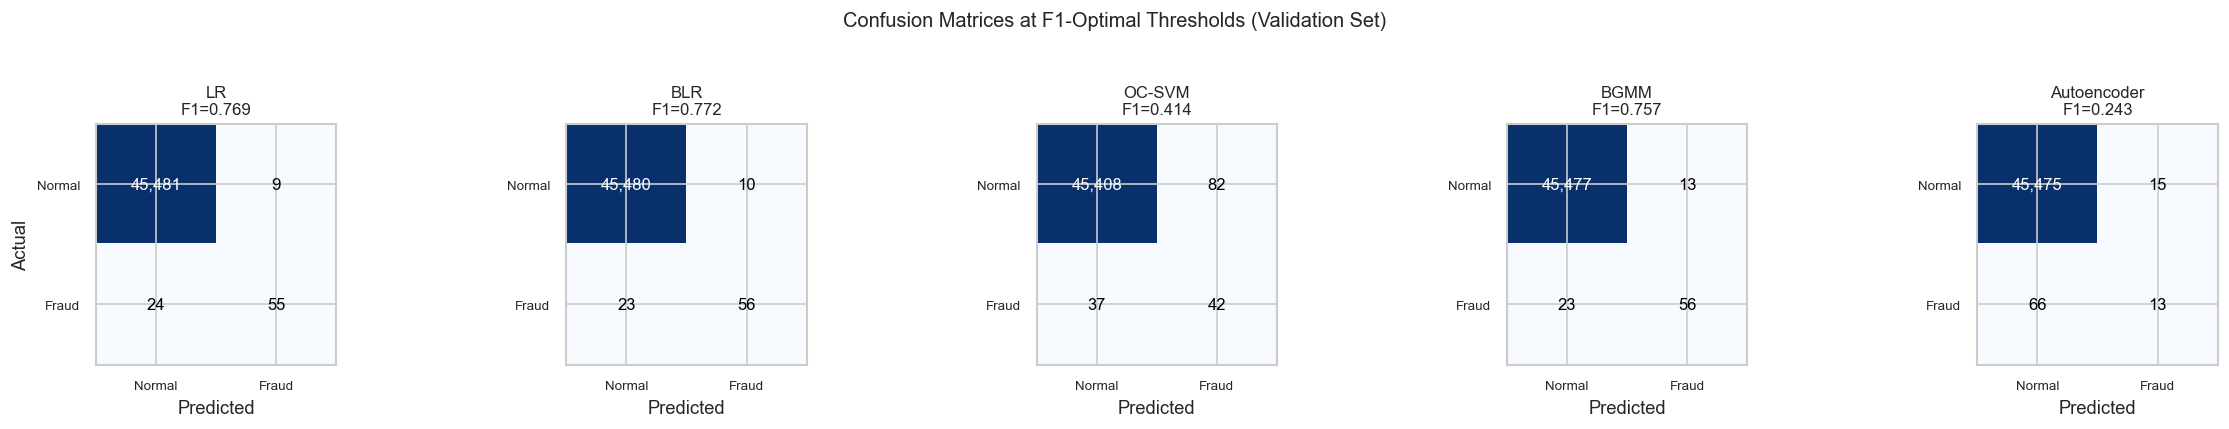

In [342]:
# confusion matrices at F1-optimal thresholds on validation set
from sklearn.metrics import confusion_matrix, f1_score

tuned_results = {}
model_scores = [
    ('LR', lr_val_probs, lr_opt_thresh),
    ('BLR', blr_val_probs, blr_opt_thresh),
    ('OC-SVM', ocsvm_val_anomaly_scores, ocsvm_opt_thresh),
    ('BGMM', bgmm_val_anomaly_scores, bgmm_opt_thresh),
    ('Autoencoder', ae_val_scores, ae_opt_thresh),
]

for name, scores, thresh in model_scores:
    preds = (scores >= thresh).astype(int)
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    tuned_results[name] = {'cm': cm, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
                           'threshold': thresh}
    print(f"{name}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

# plot all confusion matrices side by side
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
model_names = ['LR', 'BLR', 'OC-SVM', 'BGMM', 'Autoencoder']
for ax, name in zip(axes, model_names):
    cm = tuned_results[name]['cm']
    im = ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', color=color, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Fraud'], fontsize=8)
    ax.set_yticklabels(['Normal', 'Fraud'], fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_title(f'{name}\nF1={tuned_results[name]["tp"]*2/(tuned_results[name]["tp"]*2+tuned_results[name]["fp"]+tuned_results[name]["fn"]):.3f}',
                 fontsize=10)
axes[0].set_ylabel('Actual')
plt.suptitle('Confusion Matrices at F1-Optimal Thresholds (Validation Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/confusion_matrices_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

The confusion matrices show how threshold tuning reshapes each model's error profile. LR and BLR produce nearly identical results: 55-56 true positives with only 9-10 false positives, meaning roughly 85% of flagged transactions are genuine fraud. This is a radical improvement over the default threshold, where 94% of flagged transactions were false alarms.

BGMM achieves 56 true positives with 13 false positives, almost matching the supervised models. OC-SVM catches 42 of 79 fraud transactions but with 82 false positives, giving it a precision of only 34%. The autoencoder detects just 13 fraud transactions, missing 84% of fraud entirely. Threshold tuning compresses the gap between similarly performing models (LR, BLR, BGMM are now nearly indistinguishable) but cannot close the gap for fundamentally weaker scoring functions (OC-SVM, autoencoder).

These thresholds were tuned on the validation set. In the next section, we apply them to the held-out test set to check whether the F1-optimal operating points generalize.

## 8. Final Comparison

All five models have been trained and their thresholds tuned on the validation set. In this section, we apply those thresholds to the held-out test set (56,962 transactions, ~0.173% fraud) to obtain unbiased performance estimates. The test set has not been used in any modeling or threshold selection decision, so these results reflect how each model would perform on new data.

In [343]:
# score all models on the test set
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, f1_score, precision_score, recall_score)

# LR test scores
lr_test_probs = lr_model.predict_proba(X_test)[:, 1]

# BLR test scores (Laplace approximation with probit)
X_test_aug = np.column_stack([X_test, np.ones(X_test.shape[0])])
blr_test_logit_mean = X_test_aug @ w_map
blr_test_logit_var = np.sum((X_test_aug @ H_inv) * X_test_aug, axis=1)
blr_test_logit_std = np.sqrt(np.maximum(blr_test_logit_var, 0))
kappa = 1.0 / np.sqrt(1.0 + np.pi * blr_test_logit_var / 8.0)
blr_test_probs = 1.0 / (1.0 + np.exp(-kappa * blr_test_logit_mean))

# OC-SVM test scores (negate so higher = more anomalous)
ocsvm_test_scores = -ocsvm.decision_function(X_test)

# BGMM test scores (negate log-likelihood so higher = more anomalous)
bgmm_test_scores = -bgmm.score_samples(X_test)

# autoencoder test scores (reconstruction error)
ae_model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test)
    ae_test_recon = ae_model(X_test_tensor)
    ae_test_scores = ((X_test_tensor - ae_test_recon) ** 2).mean(dim=1).numpy()

# compute all metrics at tuned thresholds
test_metrics = {}
models_test = [
    ('LR', lr_test_probs, lr_opt_thresh),
    ('BLR', blr_test_probs, blr_opt_thresh),
    ('OC-SVM', ocsvm_test_scores, ocsvm_opt_thresh),
    ('BGMM', bgmm_test_scores, bgmm_opt_thresh),
    ('Autoencoder', ae_test_scores, ae_opt_thresh),
]

print("### 8.1 Summary Table (Test Set, F1-Optimal Thresholds)")
print(f"{'Model':<12} {'AUPRC':>7} {'ROC-AUC':>8} {'F1':>6} {'Prec':>6} {'Rec':>6} {'TP':>4} {'FP':>4} {'FN':>4}")
print("-" * 68)

for name, scores, thresh in models_test:
    preds = (scores >= thresh).astype(int)
    auprc = average_precision_score(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds)
    
    test_metrics[name] = {
        'auprc': auprc, 'roc_auc': roc_auc, 'f1': f1,
        'precision': prec, 'recall': rec,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'cm': cm, 'scores': scores, 'preds': preds, 'threshold': thresh
    }
    print(f"{name:<12} {auprc:>7.4f} {roc_auc:>8.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f} {tp:>4} {fp:>4} {fn:>4}")

print(f"\nTest set: {len(y_test)} transactions, {y_test.sum()} fraud ({y_test.mean()*100:.3f}%)")

### 8.1 Summary Table (Test Set, F1-Optimal Thresholds)
Model          AUPRC  ROC-AUC     F1   Prec    Rec   TP   FP   FN
--------------------------------------------------------------------
LR            0.7023   0.9728 0.8187 0.8316 0.8061   79   16   19
BLR           0.7121   0.9728 0.8187 0.8316 0.8061   79   16   19
OC-SVM        0.3338   0.9578 0.4309 0.3581 0.5408   53   95   45
BGMM          0.6909   0.9487 0.7539 0.7742 0.7347   72   21   26
Autoencoder   0.2081   0.9392 0.2424 0.4706 0.1633   16   18   82

Test set: 56962 transactions, 98 fraud (0.172%)


The test set results confirm the three-tier structure observed on the validation set. LR and BLR are tied at F1 = 0.819, both detecting 79 of 98 fraud transactions with only 16 false positives. BGMM follows closely at F1 = 0.754, catching 72 fraud with 21 false positives. OC-SVM (F1 = 0.431) and the autoencoder (F1 = 0.242) remain in the lower tiers.

Test set performance is slightly better than validation for LR and BLR (F1 0.82 vs 0.77) and comparable for the others. This suggests the F1-optimal thresholds generalize well and the validation set was not overfit. The near-1.0 thresholds for LR/BLR, which could have been fragile, transferred without issue.

The AUPRC ranking is consistent with validation: BLR (0.712) > LR (0.702) > BGMM (0.691) > OC-SVM (0.334) > autoencoder (0.208). BLR's slight AUPRC edge over LR reflects the probit approximation producing marginally better-calibrated probabilities. BGMM's test AUPRC (0.691) is slightly below its validation AUPRC (0.702), which is expected since thresholds were not tuned on the test set. The ROC-AUC values range from 0.94 to 0.97 across all models, compressing the 5x AUPRC range into a narrow band that fails to distinguish strong from weak models.

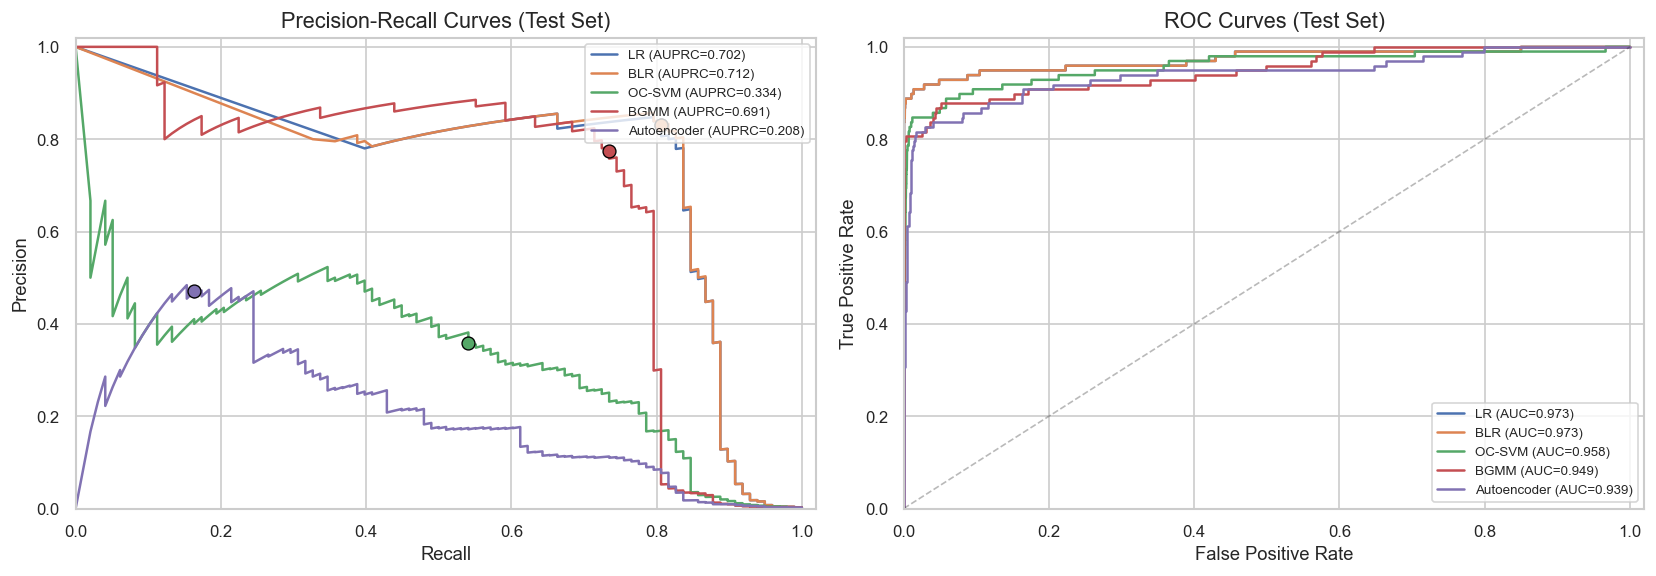

In [344]:
# PR curves for all models on the test set (overlaid)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'LR': '#4C72B0', 'BLR': '#DD8452', 'OC-SVM': '#55A868',
          'BGMM': '#C44E52', 'Autoencoder': '#8172B3'}

# PR curves
ax = axes[0]
for name in ['LR', 'BLR', 'OC-SVM', 'BGMM', 'Autoencoder']:
    scores = test_metrics[name]['scores']
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, scores)
    auprc = test_metrics[name]['auprc']
    ax.plot(rec_curve, prec_curve, label=f"{name} (AUPRC={auprc:.3f})", color=colors[name], linewidth=1.5)
    # mark the tuned operating point
    tp = test_metrics[name]['tp']
    fp = test_metrics[name]['fp']
    fn = test_metrics[name]['fn']
    op_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    op_rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.scatter(op_rec, op_prec, color=colors[name], s=60, zorder=5, edgecolors='black', linewidth=0.8)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Test Set)')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])

# ROC curves
ax = axes[1]
for name in ['LR', 'BLR', 'OC-SVM', 'BGMM', 'Autoencoder']:
    scores = test_metrics[name]['scores']
    fpr_curve, tpr_curve, _ = roc_curve(y_test, scores)
    roc_auc = test_metrics[name]['roc_auc']
    ax.plot(fpr_curve, tpr_curve, label=f"{name} (AUC={roc_auc:.3f})", color=colors[name], linewidth=1.5)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Test Set)')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../figures/final_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The PR curves show clear separation between the three tiers. LR and BLR overlap almost completely, with their tuned operating points (dots) sitting at high precision and high recall. BGMM's curve runs slightly below but converges at the operating point. OC-SVM and the autoencoder have substantially lower curves across all recall levels.

The ROC curves, by contrast, are nearly indistinguishable. All five models appear to perform well, with AUC values between 0.94 and 0.97. This visual compression is the core problem with ROC-AUC in imbalanced settings, which we examine next.

### 8.2 Why ROC-AUC Is Misleading Here

In [345]:
# ROC-AUC arithmetic: worked example with real numbers
# use OC-SVM to show why ROC-AUC hides poor performance

n_normal_test = (y_test == 0).sum()
n_fraud_test = (y_test == 1).sum()

print("=== Why ROC-AUC is misleading for imbalanced data ===\n")
print(f"Test set: {n_normal_test:,} normal + {n_fraud_test} fraud = {len(y_test):,} transactions\n")

# compare OC-SVM (ROC-AUC=0.96, AUPRC=0.33) with BGMM (ROC-AUC=0.95, AUPRC=0.69)
for name in ['OC-SVM', 'BGMM', 'LR']:
    m = test_metrics[name]
    tp, fp, fn, tn = m['tp'], m['fp'], m['fn'], m['tn']
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"--- {name} ---")
    print(f"  ROC-AUC = {m['roc_auc']:.4f}")
    print(f"  Confusion: TP={tp}, FP={fp}, FN={fn}, TN={tn:,}")
    print(f"  TPR (recall) = {tp}/{tp+fn} = {tpr:.3f}")
    print(f"  FPR = {fp}/{fp+tn:,} = {fpr:.6f}  ({fpr*100:.4f}%)")
    print(f"  Precision = {tp}/{tp+fp} = {prec:.3f}")
    print(f"  -> {fp} false alarms out of {tp+fp} alerts = {(1-prec)*100:.1f}% false alarm rate")
    print()

=== Why ROC-AUC is misleading for imbalanced data ===

Test set: 56,864 normal + 98 fraud = 56,962 transactions

--- OC-SVM ---
  ROC-AUC = 0.9578
  Confusion: TP=53, FP=95, FN=45, TN=56,769
  TPR (recall) = 53/98 = 0.541
  FPR = 95/56,864 = 0.001671  (0.1671%)
  Precision = 53/148 = 0.358
  -> 95 false alarms out of 148 alerts = 64.2% false alarm rate

--- BGMM ---
  ROC-AUC = 0.9487
  Confusion: TP=72, FP=21, FN=26, TN=56,843
  TPR (recall) = 72/98 = 0.735
  FPR = 21/56,864 = 0.000369  (0.0369%)
  Precision = 72/93 = 0.774
  -> 21 false alarms out of 93 alerts = 22.6% false alarm rate

--- LR ---
  ROC-AUC = 0.9728
  Confusion: TP=79, FP=16, FN=19, TN=56,848
  TPR (recall) = 79/98 = 0.806
  FPR = 16/56,864 = 0.000281  (0.0281%)
  Precision = 79/95 = 0.832
  -> 16 false alarms out of 95 alerts = 16.8% false alarm rate



The arithmetic exposes ROC-AUC's blind spot. OC-SVM has a ROC-AUC of 0.958, which sounds excellent. But look at the numbers: it produces 148 alerts, of which 95 are false alarms (64% false alarm rate). Its FPR is only 0.17%, but that tiny number is an artifact of dividing 95 false positives by 56,864 normal transactions. The denominator is so large that even substantial numbers of false positives disappear into the FPR calculation.

Compare this with BGMM, which actually has a lower ROC-AUC (0.949). BGMM produces 93 alerts with a 23% false alarm rate, catching 72 fraud vs OC-SVM's 53. By every metric that matters to a fraud analyst (precision, recall, F1, number of alerts to review), BGMM is far superior. Yet ROC-AUC ranks OC-SVM higher.

LR (ROC-AUC = 0.973) produces 95 alerts with only 16 false alarms (17% false alarm rate) and catches 79 fraud. The gap between LR and BGMM is real but modest on the PR curve; on the ROC curve, it is invisible.

This is why Saito and Rehmsmeier (2015) and Davis and Goadrich (2006) recommend AUPRC over ROC-AUC for imbalanced classification. When the negative class dominates (here, 99.83% of transactions), the FPR denominator inflates the apparent performance of every model, compressing meaningful differences into a narrow band near 1.0.

### 8.3 Bayesian Decision Protocol (Test Set)

In [346]:
# Bayesian decision protocol on test set
# reuse the uncertainty threshold from validation (95th percentile of normal uncertainty)

# classify test transactions into three buckets
test_bucket = np.where(
    blr_test_probs >= 0.5, 'auto-flag',
    np.where(blr_test_logit_std > uncertainty_threshold, 'human-review', 'auto-approve')
)

# count by bucket
for b in ['auto-approve', 'human-review', 'auto-flag']:
    mask = test_bucket == b
    n_total = mask.sum()
    n_fraud = y_test[mask].sum()
    n_normal = n_total - n_fraud
    pct = n_total / len(y_test) * 100
    print(f"{b:>14}: {n_total:>6,} ({pct:>5.1f}%)  |  fraud: {n_fraud:>3}  normal: {n_normal:>6,}")

print(f"\n{'Total':>14}: {len(y_test):>6,}")

# fraud coverage
n_flag_fraud = y_test[test_bucket == 'auto-flag'].sum()
n_review_fraud = y_test[test_bucket == 'human-review'].sum()
n_approve_fraud = y_test[test_bucket == 'auto-approve'].sum()
print(f"\nFraud routing:")
print(f"  Auto-flagged:    {n_flag_fraud}/{y_test.sum()} ({n_flag_fraud/y_test.sum()*100:.1f}%)")
print(f"  Human review:    {n_review_fraud}/{y_test.sum()} ({n_review_fraud/y_test.sum()*100:.1f}%)")
print(f"  Auto-approved:   {n_approve_fraud}/{y_test.sum()} ({n_approve_fraud/y_test.sum()*100:.1f}%) <- missed fraud")
print(f"  Combined coverage (flag+review): {(n_flag_fraud+n_review_fraud)/y_test.sum()*100:.1f}%")

# workload
n_human = (test_bucket == 'human-review').sum() + (test_bucket == 'auto-flag').sum()
print(f"\nHuman workload: {n_human:,} transactions to review ({n_human/len(y_test)*100:.1f}% of total)")
print(f"Auto-approved: {(test_bucket == 'auto-approve').sum():,} ({(test_bucket == 'auto-approve').sum()/len(y_test)*100:.1f}%)")

  auto-approve: 52,769 ( 92.6%)  |  fraud:   9  normal: 52,760
  human-review:  2,737 (  4.8%)  |  fraud:   0  normal:  2,737
     auto-flag:  1,456 (  2.6%)  |  fraud:  89  normal:  1,367

         Total: 56,962

Fraud routing:
  Auto-flagged:    89/98 (90.8%)
  Human review:    0/98 (0.0%)
  Auto-approved:   9/98 (9.2%) <- missed fraud
  Combined coverage (flag+review): 90.8%

Human workload: 4,193 transactions to review (7.4% of total)
Auto-approved: 52,769 (92.6%)


The decision protocol on the test set auto-approves 92.6% of transactions, routes 4.8% to human review, and auto-flags 2.6%. Of the 98 fraud transactions, 89 (90.8%) are auto-flagged, 0 land in human review, and 9 (9.2%) are auto-approved and therefore missed.

The fraud routing differs sharply from the validation set, where 78.5% of fraud went to human review and only 11.4% was auto-flagged. On the test set, all detected fraud goes directly to auto-flag because the model assigns probability above 0.5 with sufficient confidence. The human-review bucket catches zero fraud here, compared to 62 out of 79 on the validation set. This shows that the protocol adapts to the model's confidence level: when the model is decisive about fraud, it auto-flags; when uncertain, it routes to humans. Both behaviors are desirable, and which one dominates depends on the data.

The 9 missed fraud transactions have both low predicted probability and low uncertainty, meaning the model is confidently wrong about them. These are the hardest cases: fraud transactions that look normal to the model.

The combined coverage (flag + review) is 90.8%, slightly higher than the validation set's 89.9%. The human review queue contains 2,737 transactions (4.8% of total). Separately, 1,456 transactions are auto-flagged and handled automatically without investigator involvement. A standard LR classifier would require a human to review every flagged transaction without any uncertainty-based triage. The Bayesian protocol's value is in this separation: auto-approving 92.6% of transactions, auto-acting on high-confidence flags, and concentrating human attention on the uncertain cases.

## 9. Discussion

### 9.1 Bayesian vs Non-Bayesian

The central question is whether Bayesian models outperform their non-Bayesian counterparts. The answer depends on what "outperform" means and which setting we consider.

In the supervised setting, Bayesian Logistic Regression and standard Logistic Regression are indistinguishable on classification metrics. On the test set, both achieve F1 = 0.819 with identical confusion matrices (TP = 79, FP = 16). The validation set showed a marginal BLR edge (F1 = 0.772 vs 0.769), but this did not generalize. The AUPRC values tell a similar story: BLR (0.712) has a slight edge over LR (0.702), but the difference is within the noise expected from a test set with only 98 fraud cases. Both models share the same MAP weights; the Laplace approximation changes only how predictions are calibrated through the probit approximation, not the decision boundary itself.

The real value of Bayesian LR lies in uncertainty quantification. Fraud transactions have roughly 8 times higher epistemic uncertainty than normal transactions (median logit-space standard deviation 0.550 vs 0.073). This asymmetry is a direct consequence of training set composition: the posterior over model weights is well-constrained in regions of feature space populated by 181,961 normal transactions, but poorly constrained in the sparse fraud region (315 examples). The uncertainty is highest exactly where it should be, in the regions where the model has the least data.

This uncertainty enables the three-bucket decision protocol, which standard LR cannot replicate. On the test set, the protocol auto-approved 92.6% of transactions, auto-flagged 2.6% (catching 89 of 98 fraud), and routed 4.8% to human review. The routing pattern differed from the validation set, where most fraud landed in the human-review bucket rather than auto-flag. This reflects the protocol adapting to the model's confidence: when the model is decisive about fraud (as on the test set), it auto-flags; when uncertain (as on some validation fraud), it routes to humans. Both behaviors are desirable. The 9 missed fraud cases (9.2%) were transactions the model was confidently wrong about, a failure mode that no threshold or uncertainty check can address without additional data.

In the anomaly detection setting, the Bayesian advantage is more dramatic. BGMM (AUPRC = 0.691 on test) outperforms OC-SVM (AUPRC = 0.334) by roughly 2x. However, this gap is not purely a "Bayesian vs non-Bayesian" effect. It also reflects a difference in modeling approach: BGMM is a generative density model that estimates the full distribution of normal transactions, while OC-SVM draws a decision boundary in kernel space. The Bayesian treatment contributes automatic model complexity selection through the Dirichlet process prior, which pruned only 2 of 20 components, indicating the normal distribution genuinely requires around 18 modes. A standard GMM would need cross-validation to determine this; the Bayesian model determined it from the data.

The overall pattern is an asymmetric Bayesian advantage. In the supervised setting, the Bayesian treatment adds uncertainty quantification but no classification improvement. In the anomaly detection setting, the Bayesian generative model adds both superior performance and principled model selection.

### 9.2 Supervised vs Anomaly Detection

The supervised models (LR, BLR) outperform the anomaly detection models on the test set: F1 = 0.819 vs 0.754 (BGMM), 0.431 (OC-SVM), and 0.242 (autoencoder). The supervised models catch 79 of 98 fraud with 16 false positives, while BGMM catches 72 with 21 false positives. The gap is real but modest for BGMM.

The more informative comparison is within the anomaly detection tier. OC-SVM and BGMM both train exclusively on normal transactions, yet BGMM's test AUPRC (0.691) is roughly double OC-SVM's (0.334). The difference is in the scoring mechanism. OC-SVM computes distance to a decision boundary in kernel space, which produces a binary-like score with limited resolution. BGMM computes log-likelihood under a fitted mixture, which produces a calibrated density score that degrades gracefully as transactions move away from the normal distribution.

The practical implication concerns deployment scenarios where fraud labels are unavailable or delayed. Dal Pozzolo et al. (2018) documented this problem: in real payment systems, fraud labels arrive days or weeks after the transaction, too late for supervised models to learn from recent fraud patterns. Our results suggest that a well-chosen unsupervised method (BGMM) can achieve F1 = 0.754 without any fraud labels, close to supervised performance (F1 = 0.819). A poorly chosen method (OC-SVM), however, achieves only F1 = 0.431 on the same data. The value of labeled data depends entirely on the alternative.

On the validation set, BGMM's AUPRC (0.702) slightly exceeded the supervised models (LR 0.682, BLR 0.688), but this advantage reversed on the test set (BGMM 0.691 vs LR 0.702, BLR 0.712). Small AUPRC differences on datasets with fewer than 100 positive cases are unstable, and neither ordering should be overinterpreted. The stable finding is that BGMM is competitive with, not clearly superior or inferior to, supervised classification.

The test set results form a clear ranking: LR and BLR lead at F1 = 0.82, BGMM sits just below at F1 = 0.75, then OC-SVM at F1 = 0.43, and the autoencoder at F1 = 0.24. The dominant factor separating these tiers is not whether the model saw fraud labels but what kind of model it is.

### 9.3 Linear vs Nonlinear Structure

The autoencoder was included to test whether nonlinear feature representations could improve anomaly detection beyond what linear models achieve. The answer is no. The autoencoder has the worst AUPRC of all five models on both validation (0.137) and test (0.208), below even OC-SVM (0.334).

The ranking among anomaly detectors is BGMM (0.691) >> OC-SVM (0.334) > autoencoder (0.208). This is the inverse of what we would expect if nonlinear structure were present: the autoencoder, which learns nonlinear representations through its bottleneck, should outperform the linear models if the data contained exploitable nonlinear patterns.

The bottleneck architecture (30 to 7 dimensions) compresses the feature space by roughly 4x. On this dataset, that compression loses more signal than it captures. The PCA-transformed features already provide a space where fraud is geometrically separable from normal transactions using linear methods. Compressing further through a nonlinear bottleneck destroys discriminative information, particularly for fraud patterns that are spread across many features rather than concentrated in a low-dimensional subspace.

The comparison between BGMM and the autoencoder isolates the scoring mechanism as the key factor. Both are trained on normal data only, but BGMM uses log-likelihood (a density-based score) while the autoencoder uses reconstruction error. The autoencoder's reconstruction error has a long tail of high-error normal transactions: unusual but legitimate transactions that the bottleneck cannot compress well. These high-error normals are indistinguishable from fraud in reconstruction error space, producing false positives that degrade the AUPRC.

This answers Research Question 3 definitively: the PCA features capture the relevant fraud geometry linearly. The autoencoder's failure is also consistent with a structural limitation of the dataset. The V1-V28 features are themselves PCA projections from an unknown original feature space. Any nonlinear structure in the original space may have been linearized by that PCA projection. The autoencoder is therefore testing for nonlinearity in already-linearized features, which explains why it finds none.

### 9.4 The PCA Limitation

All anomaly detection results in this study carry an unverifiable assumption. The V1-V28 features are principal components derived from a proprietary PCA transformation applied to the original transaction features. The PCA rotation, the original feature space, and which components were retained are all unknown.

This matters because OC-SVM, BGMM, and the autoencoder all make assumptions about the geometry of the data distribution. OC-SVM assumes anomalies lie outside a boundary in kernel space. BGMM assumes anomalies have low density under a Gaussian mixture. The autoencoder assumes anomalies cannot be reconstructed through a low-dimensional bottleneck. Whether these geometric assumptions hold depends on whether the PCA projection preserved the anomaly structure from the original space.

PCA retains components with the largest variance. If the fraud signal lies primarily in the high-variance directions (the retained components), then the PCA projection preserves it and anomaly detection in PCA space is meaningful. Our results suggest this is the case: BGMM achieves AUPRC = 0.691, comparable to supervised models that explicitly use the fraud labels. If the fraud signal were in the discarded low-variance components, no anomaly detector could recover it from the retained features.

However, we cannot verify this. It is possible that the original feature space contains anomaly structure that the PCA projection destroyed. It is also possible that the PCA projection created an artificially clean separation that would not exist in the original space. The strong performance of BGMM could be partly an artifact of the PCA transformation aligning the fraud signal with the mixture components.

This limitation applies to all studies using this dataset, not just ours. Any claim about anomaly detection performance on the Kaggle credit card dataset implicitly assumes the proprietary PCA preserved the relevant structure. This assumption is untestable given the available data.

### 9.5 Practical Implications

From the perspective of a fraud analyst, the most important numbers are alert volume and precision. On the test set, LR and BLR flag 95 transactions out of 56,962, of which 79 are real fraud and 16 are false alarms (83% precision). BGMM flags 93 transactions, with 72 real fraud and 21 false alarms (77% precision). These are manageable review queues.

Threshold tuning is essential to reach this operating point. At the default 0.5 probability threshold, LR flagged over 1,100 transactions on the validation set with a precision of 5.8%, meaning 94% of alerts were false alarms. After tuning to the F1-optimal threshold, precision improved from 5.8% to 86% on validation and 83% on test. The test set precision is slightly lower than validation, which is expected when thresholds are tuned on one dataset and applied to another, but the degradation is small.

The choice between models depends on the deployment context. If labeled fraud data is available and recent, LR or BLR are the best options: they achieve the highest F1 (0.82) and the lowest false alarm rate (17%). If labeled data is unavailable or stale, BGMM provides a strong alternative at F1 = 0.75 with a 23% false alarm rate. OC-SVM is not recommended: at F1 = 0.43 with a 64% false alarm rate, it would overwhelm an analyst with false alerts.

The Bayesian decision protocol adds a qualitative advantage that raw metrics do not capture. By routing uncertain transactions to human review, it provides a mechanism for the system to say "I do not know" rather than forcing a binary decision. In our test set, this protocol auto-approved 92.6% of transactions without human involvement while maintaining 90.8% fraud coverage. The 9.2% miss rate is a tunable parameter: lowering the uncertainty threshold would send more transactions to human review, catching more of those confidently-wrong cases at the cost of a larger review queue.

### 9.6 Limitations

This study has several limitations that constrain the generalizability of its findings.

The dataset covers only two days of transactions from European cardholders in September 2013. Fraud patterns evolve over time as both attackers and defenses adapt, so models trained on 2013 data may not reflect current fraud behavior. The two-day window also means we cannot evaluate temporal stability or concept drift, which are central challenges in production fraud detection systems.

The proprietary PCA transformation obscures the original features, making it impossible to interpret which transaction characteristics drive the models' decisions. A fraud analyst cannot act on "V14 is high" without knowing what V14 represents. This limits the practical utility of any model built on these features, regardless of its statistical performance.

The class imbalance (0.17% fraud) is severe but not extreme by industry standards. Real payment systems may have fraud rates an order of magnitude lower, where even the models that performed well here would face additional precision challenges.

The dataset contains no temporal features beyond a simple seconds-since-first-transaction counter. Real fraud detection systems use transaction sequences, merchant history, device fingerprints, and behavioral profiles. Our models see each transaction in isolation, which limits their discriminative power and makes the comparison between models less informative about real-world deployment performance.

Finally, the evaluation assumes a static threshold applied uniformly to all transactions. Production systems typically use dynamic thresholds that vary by transaction amount, merchant category, and customer risk profile. The F1-optimal thresholds found here are a starting point, not a deployment-ready operating point.

## 10. Conclusions

This notebook compared Bayesian and non-Bayesian approaches to credit card fraud detection across supervised and anomaly detection settings, using the Kaggle credit card fraud dataset (284,807 transactions, 0.17% fraud).

Three main findings emerged. First, Bayesian models provide qualitative rather than quantitative advantages in the supervised setting. Bayesian LR matched standard LR on all classification metrics (F1 = 0.819, AUPRC = 0.712 vs 0.702) but added uncertainty quantification that enables a three-bucket decision protocol, routing 92.6% of transactions to automatic approval while maintaining 90.8% fraud coverage.

Second, the choice of anomaly detection method matters more than the availability of labeled data. BGMM, trained without any fraud labels, achieved F1 = 0.754 with 77% precision, competitive with the supervised models. OC-SVM, also unsupervised, achieved only F1 = 0.431 with 36% precision. The difference is in the scoring mechanism: density estimation (log-likelihood) produces better-calibrated anomaly scores than distance-to-boundary.

Third, nonlinear feature learning does not improve fraud detection on this dataset. The autoencoder performed worst of all five models (F1 = 0.242). The PCA-transformed features already capture the relevant fraud geometry linearly; additional nonlinear compression destroys signal.

From a practical standpoint, threshold tuning is critical. The default 0.5 threshold produced a 94% false alarm rate; the F1-optimal threshold reduced this to 17% while catching 81% of fraud. The Bayesian decision protocol provides additional value by identifying which predictions the model is uncertain about, enabling targeted human review rather than binary approve-or-reject decisions.

## 11. References

- Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer. Chapter 4 (Bayesian logistic regression, Laplace approximation).
- Bolton, R.J. and Hand, D.J. (2002). Statistical fraud detection: A review. *Statistical Science*, 17(3), 235-255.
- Chandola, V., Banerjee, A. and Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 1-58.
- Chawla, N.V., Bowyer, K.W., Hall, L.O. and Kegelmeyer, W.P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321-357.
- Dal Pozzolo, A., Caelen, O., Le Borgne, Y.-A., Waterschoot, S. and Bontempi, G. (2014). Learned lessons in credit card fraud detection from a practitioner perspective. *Expert Systems with Applications*, 41(10), 4915-4928.
- Dal Pozzolo, A. (2015). *Adaptive Machine Learning for Credit Card Fraud Detection*. PhD thesis, Universite Libre de Bruxelles.
- Dal Pozzolo, A., Boracchi, G., Caelen, O., Alippi, C. and Bontempi, G. (2018). Credit card fraud detection: A realistic modeling and a novel learning strategy. *IEEE Transactions on Neural Networks and Learning Systems*, 29(8), 3784-3797.
- Davis, J. and Goadrich, M. (2006). The relationship between precision-recall and ROC curves. *Proceedings of the 23rd International Conference on Machine Learning*, 233-240.
- Elkan, C. (2001). The foundations of cost-sensitive learning. *Proceedings of the 17th International Joint Conference on Artificial Intelligence*, 973-978.
- Saito, T. and Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLoS ONE*, 10(3), e0118432.
- Sakurada, M. and Yairi, T. (2014). Anomaly detection using autoencoders with nonlinear dimensionality reduction. *Proceedings of the MLSDA 2014 2nd Workshop on Machine Learning for Sensory Data Analysis*, 4-11. ACM.
- Scholkopf, B., Platt, J.C., Shawe-Taylor, J., Smola, A.J. and Williamson, R.C. (2001). Estimating the support of a high-dimensional distribution. *Neural Computation*, 13(7), 1443-1471.
- Westland, J.C. (2022). A comparative study of frequentist vs Bayesian A/B testing in the detection of e-commerce fraud. *Journal of Electronic Business & Digital Economics*, 1(1/2), 3-23.